In [4]:
import boto3
import sagemaker
import os
from sagemaker.processing import (
    ProcessingInput,
    ProcessingOutput,
    ScriptProcessor,
)
from sagemaker.spark.processing import PySparkProcessor
from sagemaker import get_execution_role

In [5]:
# Configuración base
REGION = "us-east-1"
ROLE = get_execution_role()
SESSION = sagemaker.Session()

In [15]:
# Buckets
BRONZE_BUCKET = "hymmrec-dilkehousebronze01"
SILVER_BUCKET = "hymmrec-dilkehousesilver01"
GOLD_BUCKET = "hymmrec-dilkehousegold01"
PLATINUM_BUCKET = "hymmrec-sagemaker-assets"  # Para datos de entrenamiento

# Paths S3 Silver (input)
S3_SILVER_RATINGS = f"s3://{SILVER_BUCKET}/data/obt_movie_affinity/cleansed_ratings/data/"
S3_SILVER_MOVIES = f"s3://{SILVER_BUCKET}/data/obt_movie_affinity/cleansed_movies/data/"
S3_SILVER_POSTERS = f"s3://{SILVER_BUCKET}/data/imv_movie_affinity/movie_posters/"

# Paths S3 Gold (feature store / embeddings)
S3_GOLD_FEATURES = f"s3://{GOLD_BUCKET}/data/ml_feature_store/interactions/"
S3_GOLD_ENCODERS = f"s3://{PLATINUM_BUCKET}/hymmrec/model_artefacts/encoders/"
S3_GOLD_EMBEDDINGS = f"s3://{PLATINUM_BUCKET}/hymmrec/model_artefacts/embeddings/"

# Paths S3 Platinum (training datasets)
S3_PLATINUM_DATASETS = f"s3://{PLATINUM_BUCKET}/hymmrec/datasets/"

# Scripts
PROCESSING_JOB_1_SCRIPT = "processing-feature-eng-job.py"
PROCESSING_JOB_2_SCRIPT = "processing-prepare-data-splits.py"
SCRIPTS_S3_PREFIX = f"s3://{PLATINUM_BUCKET}/sagemaker-scripts/"

print(f"Role: {ROLE}")
print(f"Region: {REGION}")
print(f"Silver: {SILVER_BUCKET}")
print(f"Gold: {GOLD_BUCKET}")
print(f"Platinum: {PLATINUM_BUCKET}")

Role: arn:aws:iam::697682206292:role/sgmkr-notebook-tfm-hymm-rec-ml-iar-dev
Region: us-east-1
Silver: hymmrec-dilkehousesilver01
Gold: hymmrec-dilkehousegold01
Platinum: hymmrec-sagemaker-assets


In [16]:
local_scripts_path = "../dev/feng-data-preparing/"
s3_client = boto3.client("s3")
PROCESSING_JOB_3_SCRIPT = "processing-embeddings-job.py"

for script in [PROCESSING_JOB_1_SCRIPT, PROCESSING_JOB_2_SCRIPT, PROCESSING_JOB_3_SCRIPT]:
    local_path = os.path.join(local_scripts_path, script)
    s3_key = f"sagemaker-scripts/{script}"
    s3_client.upload_file(local_path, GOLD_BUCKET, s3_key)
    print(f"Uploaded: {local_path} → s3://{GOLD_BUCKET}/{s3_key}")

Uploaded: ../dev/processing-feature-eng-job.py → s3://hymmrec-dilkehousegold01/sagemaker-scripts/processing-feature-eng-job.py
Uploaded: ../dev/processing-prepare-data-splits.py → s3://hymmrec-dilkehousegold01/sagemaker-scripts/processing-prepare-data-splits.py
Uploaded: ../dev/processing-embeddings-job.py → s3://hymmrec-dilkehousegold01/sagemaker-scripts/processing-embeddings-job.py


In [5]:
print("=" * 60)
print("PROCESSING JOB 1: Feature Engineering + Feature Store")
print("=" * 60)

# Usamos PySparkProcessor para la parte de Spark
pyspark_processor = PySparkProcessor(
    role=ROLE,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    framework_version="3.3",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-feature-engineering",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "feature-engineering"},
    ],
)

PROCESSING JOB 1: Feature Engineering + Feature Store


In [ ]:
# Ejecutar Processing Job 1
pyspark_processor.run(
    submit_app=f"{local_scripts_path}/{PROCESSING_JOB_1_SCRIPT}",
    submit_py_files=[],
    arguments=[
        "--region", REGION,
        "--feature-group-name", "hymmrec-interactions-sm-fg",
    ],
    inputs=[
        ProcessingInput(
            source=S3_SILVER_RATINGS,
            destination="/opt/ml/processing/input/ratings",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_SILVER_MOVIES,
            destination="/opt/ml/processing/input/movies",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/encoders",
            destination=S3_GOLD_ENCODERS,
            output_name="encoders",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/feature_interactions",
            destination=S3_GOLD_FEATURES,
            output_name="feature_interactions",
        ),
    ],
    spark_event_logs_s3_uri=f"s3://{PLATINUM_BUCKET}/spark-logs/job1/",
    logs=True,
    wait=True,
)

print("✅ Processing Job 1 completado.")

INFO:sagemaker:Creating processing-job with name hymmrec-feature-engineering-2026-06-17-20-56-43-271


............06-17 20:58 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--local-spark-event-logs-dir', '/opt/ml/processing/spark-events/', '/opt/ml/processing/input/code/processing-feature-eng-job.py', '--region', 'us-east-1', '--feature-group-name', 'hymmrec-interactions-sm-fg']
06-17 20:58 smspark.cli  INFO     Raw spark options before processing: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
06-17 20:58 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/processing-feature-eng-job.py', '--region', 'us-east-1', '--feature-group-name', 'hymmrec-interactions-sm-fg']
06-17 20:58 smspark.cli  INFO     Rendered spark options: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
06-17 20:58 smspark.cli  INFO     Initializing processing job.
06-17 20:58 smspark-submit INFO     {'current_host': 'algo-1', 'current_instance_type': 'ml.m5.xlarge', 'current_group_name': 'ho

In [26]:
import pickle

# Verificar encoders
s3 = boto3.resource("s3")

obj = s3.Object(PLATINUM_BUCKET, "hymmrec/model_artefacts/encoders/encoders.pkl")
encoders = pickle.loads(obj.get()["Body"].read())
print(f"Encoders verificados:")
print(f"  le_user: {len(encoders['le_user'].classes_):,} usuarios")
print(f"  le_item: {len(encoders['le_item'].classes_):,} items")
print(f"  mlb: {len(encoders['mlb'].classes_)} géneros")

Encoders verificados:
  le_user: 610 usuarios
  le_item: 9,594 items
  mlb: 20 géneros


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MultiLabelBinarizer from version 1.3.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
# ==============================================================================
# PROCESSING JOB 2 — Multimodal Embeddings (Bedrock Nova)
# ==============================================================================
# Este job (separado para optimizar costos):
#   - Lee catálogo de películas (cleansed_movies) desde Silver
#   - Descarga posters desde Silver
#   - Genera embeddings multimodales (texto + imagen) con Amazon Bedrock Nova
#   - Usa ThreadPoolExecutor para paralelizar invocaciones a Bedrock
#   - Guarda embeddings_catalog.pkl en Gold
#
# NOTA: Este job puede correr en paralelo con Job 1 si se desea,
#       ya que no depende de sus outputs.

print("\n" + "=" * 60)
print("PROCESSING JOB 2: Multimodal Embeddings (Bedrock Nova)")
print("=" * 60)

# ScriptProcessor con SKLearn (no necesita Spark, es I/O bound)
from sagemaker.sklearn.processing import SKLearnProcessor

sklearn_processor = SKLearnProcessor(
    role=ROLE,
    instance_type="ml.t3.medium",  # I/O bound, no necesita CPU potente
    instance_count=1,
    framework_version="1.2-1",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-embeddings-gen",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "embeddings-generation"},
    ],
)


PROCESSING JOB 2: Multimodal Embeddings (Bedrock Nova)


In [ ]:
sklearn_processor.run(
    code=f"{local_scripts_path}/{PROCESSING_JOB_3_SCRIPT}",
    arguments=[
        "--region", REGION,
        "--max-workers", "10",
    ],
    inputs=[
        ProcessingInput(
            source=S3_SILVER_MOVIES,
            destination="/opt/ml/processing/input/movies",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_SILVER_POSTERS,
            destination="/opt/ml/processing/input/posters",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/embeddings",
            destination=S3_GOLD_EMBEDDINGS,
            output_name="embeddings",
        ),
    ],
    logs=True,
    wait=True,
)

print("✅ Processing Job 2 (Embeddings) completado.")

INFO:sagemaker:Creating processing-job with name hymmrec-embeddings-gen-2026-06-17-13-00-13-758


.....

In [5]:
# ==============================================================================
# PROCESSING JOB 3 — Dataset Preparation (K-Core + Splits)
# ==============================================================================
# Este job DEBE ejecutarse DESPUÉS de Job 1 y Job 2, porque:
#   - Lee features de Gold (output de Job 1)
#   - Copia embeddings de Gold al Platinum (output de Job 2)
#   - Aplica K-Core filtering (users≥20, items≥10) para eliminar ruido
#   - Split temporal-estratificado: train 80% / val 10% / test 10%
#   - Persiste cold-starts (datos descartados por k-core)
#   - Al final, Platinum tiene TODO lo que necesita el Training Job

print("\n" + "=" * 60)
print("PROCESSING JOB 3: Dataset Preparation (K-Core + Splits)")
print("=" * 60)

pyspark_processor_2 = PySparkProcessor(
    role=ROLE,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    framework_version="3.3",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-dataset-splits",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "dataset-preparation"},
    ],
)



PROCESSING JOB 3: Dataset Preparation (K-Core + Splits)


In [6]:
import sagemaker
from sagemaker.feature_store.feature_group import FeatureGroup

fg = FeatureGroup(name="hymmrec-interactions-sm-fg", sagemaker_session=sagemaker.Session())
fg_s3_uri = fg.describe()["OfflineStoreConfig"]["S3StorageConfig"]["ResolvedOutputS3Uri"]
S3_GOLD_FEATURES = f"{fg_s3_uri}/"
print(f"Feature Store path: {S3_GOLD_FEATURES}")

Feature Store path: s3://hymmrec-dilkehousegold01/data/ml_feature_store/697682206292/sagemaker/us-east-1/offline-store/hymmrec-interactions-sm-fg-1781569741/data/


In [6]:
print(f"Feature Store path: {S3_GOLD_FEATURES}")

Feature Store path: s3://hymmrec-dilkehousegold01/data/ml_feature_store/interactions/


In [ ]:
pyspark_processor_2.run(
    submit_app=f"{local_scripts_path}/{PROCESSING_JOB_2_SCRIPT}",
    submit_py_files=[],
    arguments=[
        "--min-user-interactions", "20",
        "--min-item-interactions", "10",
        "--kcore-iterations", "5",
    ],
    inputs=[
        ProcessingInput(
            source=S3_GOLD_FEATURES,
            destination="/opt/ml/processing/input/features",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_GOLD_ENCODERS,
            destination="/opt/ml/processing/input/encoders",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_GOLD_EMBEDDINGS,
            destination="/opt/ml/processing/input/embeddings",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/platinum",
            destination=S3_PLATINUM_DATASETS,
            output_name="platinum_datasets",
        ),
    ],
    spark_event_logs_s3_uri=f"s3://{PLATINUM_BUCKET}/spark-logs/job2/",
    logs=True,
    wait=True,
)

print("✅ Processing Job 3 (Data Splits) completado.")

INFO:sagemaker:Creating processing-job with name hymmrec-dataset-splits-2026-06-17-22-19-33-879


............06-17 22:21 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--local-spark-event-logs-dir', '/opt/ml/processing/spark-events/', '/opt/ml/processing/input/code/processing-prepare-data-splits.py', '--min-user-interactions', '20', '--min-item-interactions', '10', '--kcore-iterations', '5']
06-17 22:21 smspark.cli  INFO     Raw spark options before processing: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
06-17 22:21 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/processing-prepare-data-splits.py', '--min-user-interactions', '20', '--min-item-interactions', '10', '--kcore-iterations', '5']
06-17 22:21 smspark.cli  INFO     Rendered spark options: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
06-17 22:21 smspark.cli  INFO     Initializing processing job.
06-17 22:21 smspark-submit INFO     {'current_host': 'algo-1', 'current_instance_type': 'ml.m

In [17]:
print("\n" + "=" * 60)
print("PROCESSING JOB 3: Dataset Preparation (Filter + Splits)")
print("=" * 60)


# SKLearnProcessor: simple, sin Spark, sin HDFS, sin logs excesivos
from sagemaker.sklearn.processing import SKLearnProcessor

sklearn_splits_processor = SKLearnProcessor(
    role=ROLE,
    instance_type="ml.m5.large",  # 8 GB RAM — suficiente para 100K-32M
    instance_count=1,
    framework_version="1.2-1",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-dataset-splits",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "dataset-preparation"},
    ],
)

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3



PROCESSING JOB 3: Dataset Preparation (Filter + Splits)


In [19]:
sklearn_splits_processor.run(
    code=f"{local_scripts_path}/{PROCESSING_JOB_2_SCRIPT}",
    arguments=[
        "--min-user-interactions", "5",
        "--min-item-interactions", "5",
        "--train-ratio", "0.80",
        "--val-ratio", "0.10",
    ],
    inputs=[
        ProcessingInput(
            source=S3_GOLD_FEATURES,
            destination="/opt/ml/processing/input/features",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/train",
            destination=f"{S3_PLATINUM_DATASETS}train/",
            output_name="train",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/val",
            destination=f"{S3_PLATINUM_DATASETS}val/",
            output_name="val",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/test",
            destination=f"{S3_PLATINUM_DATASETS}test/",
            output_name="test",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/cold-starts",
            destination=f"{S3_PLATINUM_DATASETS}cold-starts/",
            output_name="cold_starts",
        ),
    ],
    logs=True,
    wait=True,
)

print("✅ Processing Job 3 (Data Splits) completado.")

INFO:sagemaker:Creating processing-job with name hymmrec-dataset-splits-2026-06-18-00-02-26-342


.....................2026-06-18 00:05:48,215 - INFO - [main] ============================================================
2026-06-18 00:05:48,215 - INFO - [main] Processing Job 3: Dataset Preparation (pandas)
2026-06-18 00:05:48,215 - INFO - [main]   Filter: users≥5 | items≥5
2026-06-18 00:05:48,215 - INFO - [main]   Splits: 0.8/0.1/0.1
2026-06-18 00:05:48,215 - INFO - [main] ============================================================
2026-06-18 00:05:48,215 - INFO - [main] 
[PASO 1/4] Cargando features...
2026-06-18 00:05:48,215 - INFO - [load_features] Cargando features desde: /opt/ml/processing/input/features
2026-06-18 00:05:48,441 - INFO - [load_features]   → 100,498 interacciones | 610 usuarios | 9,594 items
2026-06-18 00:05:48,441 - INFO - [main] 
[PASO 2/4] Filtrando ruido...
2026-06-18 00:05:48,441 - INFO - [filter_noise] Filtrando ruido (usuarios≥5, items≥5)...
2026-06-18 00:05:48,490 - INFO - [filter_noise]   → Eliminados por usuarios: 0
2026-06-18 00:05:48,490 - INFO - [fi

## Hyperparameter tuning and Training jobs for the models

In [13]:
import boto3
import sagemaker
import os
from sagemaker.processing import (
    ProcessingInput,
    ProcessingOutput,
    ScriptProcessor,
)
from sagemaker.spark.processing import PySparkProcessor
from sagemaker import get_execution_role

In [14]:
# Configuración base
REGION = "us-east-1"
ROLE = get_execution_role()
SESSION = sagemaker.Session()

In [15]:
import sagemaker
import os
import json
from sagemaker import get_execution_role
from sagemaker.pytorch import PyTorch
from sagemaker.tuner import (
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
    IntegerParameter,
)

# Configuración base
REGION = "us-east-1"
ROLE = get_execution_role()
SESSION = sagemaker.Session()

# Buckets
PLATINUM_BUCKET = "hymmrec-sagemaker-assets"
GOLD_BUCKET = "hymmrec-dilkehousegold01"

# Paths S3 (Outputs de los Processing Jobs)
S3_PLATINUM_DATASETS = f"s3://{PLATINUM_BUCKET}/hymmrec/datasets/"
S3_PLATINUM_EMBEDDINGS = f"s3://{PLATINUM_BUCKET}/hymmrec/model_artefacts/embeddings/"
S3_PLATINUM_ENCODERS = f"s3://{PLATINUM_BUCKET}/hymmrec/model_artefacts/encoders/"

# Outputs de Training
S3_MODEL_OUTPUT = f"s3://{PLATINUM_BUCKET}/hymmrec/models/"
S3_TRAINING_SCRIPTS = f"s3://{PLATINUM_BUCKET}/sagemaker-scripts/training/"

# Instancia de Training (GPU)
#TRAINING_INSTANCE_TYPE = "ml.g4dn.xlarge"  # 1x T4 GPU, 16GB RAM, 4 vCPU
TRAINING_INSTANCE_TYPE = "ml.m5.2xlarge"

#HPO_INSTANCE_TYPE = "ml.g4dn.xlarge"
HPO_INSTANCE_TYPE = "ml.m5.2xlarge"

# Scripts locales (relativos al notebook)
LOCAL_TRAINING_DIR = "../dev/training/"

print(f"Role: {ROLE}")
print(f"Region: {REGION}")
print(f"Datasets: {S3_PLATINUM_DATASETS}")
print(f"Embeddings: {S3_PLATINUM_EMBEDDINGS}")
print(f"Model Output: {S3_MODEL_OUTPUT}")
print(f"Training Instance: {TRAINING_INSTANCE_TYPE}")

Role: arn:aws:iam::697682206292:role/sgmkr-notebook-tfm-hymm-rec-ml-iar-dev
Region: us-east-1
Datasets: s3://hymmrec-sagemaker-assets/hymmrec/datasets/
Embeddings: s3://hymmrec-sagemaker-assets/hymmrec/model_artefacts/embeddings/
Model Output: s3://hymmrec-sagemaker-assets/hymmrec/models/
Training Instance: ml.m5.2xlarge


In [16]:
# ==============================================================================
# UPLOAD SCRIPTS DE TRAINING A S3
# ==============================================================================
s3_client = boto3.client("s3")

training_scripts = [
    "nn_hymmrec.py",
    "dataloaders.py",
    "train_hymmrec_regression.py",
    "hpo_hymmrec_regression.py",
    "train_hymmrec_twoheads.py",
    "hpo_hymmrec_twoheads.py",
]

for script in training_scripts:
    local_path = os.path.join(LOCAL_TRAINING_DIR, script)
    s3_key = f"sagemaker-scripts/training/{script}"
    s3_client.upload_file(local_path, PLATINUM_BUCKET, s3_key)
    print(f"Uploaded: {local_path} → s3://{PLATINUM_BUCKET}/{s3_key}")

print("\nTodos los scripts subidos correctamente.")

Uploaded: ../dev/training/nn_hymmrec.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/training/nn_hymmrec.py
Uploaded: ../dev/training/dataloaders.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/training/dataloaders.py
Uploaded: ../dev/training/train_hymmrec_regression.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/training/train_hymmrec_regression.py
Uploaded: ../dev/training/hpo_hymmrec_regression.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/training/hpo_hymmrec_regression.py
Uploaded: ../dev/training/train_hymmrec_twoheads.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/training/train_hymmrec_twoheads.py
Uploaded: ../dev/training/hpo_hymmrec_twoheads.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/training/hpo_hymmrec_twoheads.py

Todos los scripts subidos correctamente.


In [17]:
# ==============================================================================
# VERIFICAR QUE LOS DATASETS EXISTEN
# ==============================================================================
print("\nVerificando datasets en S3...")

s3 = boto3.resource("s3")
bucket = s3.Bucket(PLATINUM_BUCKET)

# Verificar splits
for split in ["train", "val", "test"]:
    prefix = f"hymmrec/datasets/{split}/"
    objects = list(bucket.objects.filter(Prefix=prefix).limit(3))
    if objects:
        total_size = sum(obj.size for obj in objects)
        print(f"  ✅ {split}/: {len(objects)} archivos ({total_size / 1024 / 1024:.1f} MB)")
    else:
        print(f"  ❌ {split}/: NO ENCONTRADO - Ejecutar Processing Jobs primero")

# Verificar embeddings
emb_prefix = "hymmrec/model_artefacts/embeddings/"
emb_objects = list(bucket.objects.filter(Prefix=emb_prefix).limit(3))
if emb_objects:
    print(f"  ✅ embeddings/: {len(emb_objects)} archivos")
else:
    print(f"  ❌ embeddings/: NO ENCONTRADO")


Verificando datasets en S3...
  ✅ train/: 1 archivos (1.0 MB)
  ✅ val/: 1 archivos (0.2 MB)
  ✅ test/: 1 archivos (0.2 MB)
  ✅ embeddings/: 1 archivos


In [ ]:
# ==============================================================================
# HPO JOB — REGRESIÓN (Rating Prediction)
# ==============================================================================
# Busca la mejor combinación de hyperparámetros para el modelo de regresión.
# Single-Head: una sola cabeza que predice rating escalado [0,1] con MSELoss.

print("\n" + "=" * 60)
print("HPO JOB: REGRESIÓN (Rating Prediction — Single-Head)")
print("=" * 60)

# Estimador base para HPO de regresión
regression_estimator = PyTorch(
    entry_point="hpo_hymmrec_regression.py",
    source_dir=LOCAL_TRAINING_DIR,
    role=ROLE,
    instance_type=HPO_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-hpo-regression",
    hyperparameters={
        "epochs": 15,
        "patience": 3,
        "num_workers": 2,
    },
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "hpo-regression"},
    ],
)

# Definir rangos de hyperparámetros
regression_hp_ranges = {
    "lr": ContinuousParameter(0.0001, 0.01, scaling_type="Logarithmic"),
    "batch_size": CategoricalParameter([128, 256, 512]),
    "emb_dim": CategoricalParameter([32, 64, 128]),
    "dropout": ContinuousParameter(0.1, 0.5),
    "weight_decay": ContinuousParameter(1e-6, 1e-3, scaling_type="Logarithmic"),
}

# Métrica objetivo
regression_objective_metric = {
    "Name": "val_rmse_stars",
    "Regex": r"val_rmse_stars=(.*?);",
}

# Crear Tuner
regression_tuner = HyperparameterTuner(
    estimator=regression_estimator,
    objective_metric_name=regression_objective_metric["Name"],
    hyperparameter_ranges=regression_hp_ranges,
    metric_definitions=[
        regression_objective_metric,
        {"Name": "train_mse", "Regex": r"train_mse=(.*?);"},
        {"Name": "val_mse", "Regex": r"val_mse=(.*?);"},
        {"Name": "test_rmse_stars", "Regex": r"test_rmse_stars=(.*?);"},
        {"Name": "lr", "Regex": r"lr=(.*?);"},
    ],
    objective_type="Minimize",
    max_jobs=12,
    max_parallel_jobs=3,
    strategy="Bayesian",
    base_tuning_job_name="hymmrec-hpo-reg",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "hpo-regression"},
    ],
)

# Lanzar HPO
regression_tuner.fit(
    inputs={
        "train": S3_PLATINUM_DATASETS,
        "embeddings": S3_PLATINUM_EMBEDDINGS,
    },
    wait=True,
    logs="All",
)

print("✅ HPO Regresión completado.")

# Obtener mejores hyperparámetros
best_regression_hp = regression_tuner.best_training_job()
print(f"\nMejor job: {best_regression_hp}")

regression_tuner_analytics = regression_tuner.analytics()
best_regression_result = regression_tuner_analytics.dataframe().sort_values(
    "FinalObjectiveValue"
).iloc[0]
print(f"Mejor val_rmse_stars: {best_regression_result['FinalObjectiveValue']:.4f}")
print(f"Hyperparámetros óptimos:")
for col in regression_tuner_analytics.dataframe().columns:
    if col.startswith("lr") or col.startswith("batch") or col.startswith("emb") or col.startswith("dropout") or col.startswith("weight"):
        print(f"  {col}: {best_regression_result[col]}")


HPO JOB: REGRESIÓN (Rating Prediction — Single-Head)


No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config


..............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [8]:
regression_tuner.best_estimator().hyperparameters()


2026-06-22 12:37:12 Starting - Preparing the instances for training
2026-06-22 12:37:12 Downloading - Downloading the training image
2026-06-22 12:37:12 Training - Training image download completed. Training in progress.
2026-06-22 12:37:12 Uploading - Uploading generated training model
2026-06-22 12:37:12 Completed - Resource reused by training job: hymmrec-hpo-reg-260622-1229-006-f9a3cb65


{'_tuning_objective_metric': '"val_rmse_stars"',
 'batch_size': '"128"',
 'dropout': '0.4986427569205981',
 'emb_dim': '"128"',
 'epochs': '15',
 'lr': '0.0003674917687698108',
 'num_workers': '2',
 'patience': '3',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"hymmrec-hpo-regression-2026-06-22-12-29-03-852"',
 'sagemaker_program': '"hpo_hymmrec_regression.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-697682206292/hymmrec-hpo-regression-2026-06-22-12-29-03-852/source/sourcedir.tar.gz"',
 'weight_decay': '2.931833989830499e-06'}

In [18]:
# ==============================================================================
# TRAINING JOB FINAL — REGRESIÓN (con mejores HPs)
# ==============================================================================
print("\n" + "=" * 60)
print("TRAINING JOB FINAL: REGRESIÓN (Single-Head)")
print("=" * 60)

# Extraer mejores HPs del tuner
#best_reg_hps = regression_tuner.best_estimator().hyperparameters()
best_reg_hps = {'_tuning_objective_metric': '"val_rmse_stars"',
 'batch_size': '"128"',
 'dropout': '0.4986427569205981',
 'emb_dim': '"128"',
 'epochs': '15',
 'lr': '0.0003674917687698108',
 'num_workers': '2',
 'patience': '3',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"hymmrec-hpo-regression-2026-06-22-12-29-03-852"',
 'sagemaker_program': '"hpo_hymmrec_regression.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-697682206292/hymmrec-hpo-regression-2026-06-22-12-29-03-852/source/sourcedir.tar.gz"',
 'weight_decay': '2.931833989830499e-06'}

regression_final_estimator = PyTorch(
    entry_point="train_hymmrec_regression.py",
    source_dir=LOCAL_TRAINING_DIR,
    role=ROLE,
    instance_type=TRAINING_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-train-regression",
    output_path=f"{S3_MODEL_OUTPUT}regression/",
    hyperparameters={
        "epochs": 30,  # Más épocas para entrenamiento final
        "patience": 5,  # Más paciencia
        "batch_size": int(best_reg_hps.get("batch_size", "256").strip('"')),
        "lr": float(best_reg_hps.get("lr", 0.001)),
        "emb_dim": int(best_reg_hps.get("emb_dim", "64").strip('"')),
        "dropout": float(best_reg_hps.get("dropout", 0.3)),
        "weight_decay": float(best_reg_hps.get("weight_decay", 1e-5)),
        "num_workers": 2,
        # LR Scheduler
        "scheduler_patience": 2,
        "scheduler_factor": 0.5,
        "min_lr": 1e-6,
    },
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "training-regression-final"},
    ],
)

regression_final_estimator.fit(
    inputs={
        "train": S3_PLATINUM_DATASETS,
        "embeddings": S3_PLATINUM_EMBEDDINGS,
        "encoders": S3_PLATINUM_ENCODERS,
    },
    wait=True,
    logs="All",
)

print("✅ Training Regresión completado.")
print(f"Modelo: {regression_final_estimator.model_data}")

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.



TRAINING JOB FINAL: REGRESIÓN (Single-Head)


INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: hymmrec-train-regression-2026-06-23-15-45-01-893


2026-06-23 15:45:02 Starting - Starting the training job...
2026-06-23 15:45:26 Starting - Preparing the instances for training...
2026-06-23 15:46:05 Downloading - Downloading the training image......
2026-06-23 15:47:01 Training - Training image download completed. Training in progress...bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
/opt/conda/lib/python3.10/site-packages/paramiko/pkey.py:100: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
/opt/conda/lib/python3.10/site-packages/paramiko/transport.py:259: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
2026-06-23 15:47:15,756 sagemaker-training-toolkit INFO     Imported 

In [ ]:
# ==============================================================================
# HPO JOB — MULTI-TASK TWO-HEADS (Retrieval + Calidad)
# ==============================================================================
# Busca la mejor combinación de hyperparámetros para el modelo de dos cabezas.
# Cabeza 1: BCE (ranking/retrieval) sobre TODOS los datos
# Cabeza 2: MSE (calidad) ENMASCARADO solo sobre interacciones positivas
# Loss Total = BCE + MSE(positivos)

print("\n" + "=" * 60)
print("HPO JOB: MULTI-TASK TWO-HEADS (Retrieval + Calidad)")
print("=" * 60)

twoheads_estimator = PyTorch(
    entry_point="hpo_hymmrec_twoheads.py",
    source_dir=LOCAL_TRAINING_DIR,
    role=ROLE,
    instance_type=HPO_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-hpo-twoheads",
    hyperparameters={
        "epochs": 15,
        "patience": 3,
        "neg_ratio": 4,
        "num_workers": 2,
    },
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "hpo-twoheads"},
    ],
)

# Rangos de HPs para two-heads (incluye num_negatives)
twoheads_hp_ranges = {
    "lr": ContinuousParameter(0.0001, 0.01, scaling_type="Logarithmic"),
    "batch_size": CategoricalParameter([128, 256, 512]),
    "emb_dim": CategoricalParameter([32, 64, 128]),
    "dropout": ContinuousParameter(0.1, 0.5),
    "weight_decay": ContinuousParameter(1e-6, 1e-3, scaling_type="Logarithmic"),
    #"num_negatives": CategoricalParameter([10, 20, 50]),
}

#twoheads_objective_metric = {
#    "Name": "val_total_loss",
#    "Regex": r"val_total_loss=(.*?);",
#}

twoheads_objective_metric = {
    "Name": "val_bce",
    "Regex": r"val_bce=(.*?);",
}

twoheads_tuner = HyperparameterTuner(
    estimator=twoheads_estimator,
    objective_metric_name=twoheads_objective_metric["Name"],
    hyperparameter_ranges=twoheads_hp_ranges,
#    metric_definitions=[
#        twoheads_objective_metric,
#        {"Name": "train_total_loss", "Regex": r"train_total_loss=(.*?);"},
#        {"Name": "val_bce", "Regex": r"val_bce=(.*?);"},
#        {"Name": "val_mse", "Regex": r"val_mse=(.*?);"},
#        {"Name": "val_rmse_stars", "Regex": r"val_rmse_stars=(.*?);"},
#        {"Name": "test_total_loss", "Regex": r"test_total_loss=(.*?);"},
#        {"Name": "test_rmse_stars", "Regex": r"test_rmse_stars=(.*?);"},
#        {"Name": "lr", "Regex": r"lr=(.*?);"},
#    ],
    metric_definitions = [
    twoheads_objective_metric,
        {"Name": "train_total_loss", "Regex": r"train_total_loss=(.*?);"},
        {"Name": "train_bce", "Regex": r"train_bce=(.*?);"},
        {"Name": "val_total_loss", "Regex": r"val_total_loss=(.*?);"},
        {"Name": "val_mse", "Regex": r"val_mse=(.*?);"},
        {"Name": "val_rmse_stars", "Regex": r"val_rmse_stars=(.*?);"},
        {"Name": "test_bce", "Regex": r"test_bce=(.*?);"},
        #{"Name": "test_mse", "Regex": r"test_mse=(.*?);"},
        {"Name": "test_rmse_stars", "Regex": r"test_rmse_stars=(.*?);"},
        {"Name": "test_total_loss", "Regex": r"test_total_loss=(.*?);"},
        {"Name": "lr", "Regex": r"lr=(.*?);"},
    ],
    objective_type="Minimize",
    max_jobs=16,  # Más jobs porque tenemos un HP extra (num_negatives)
    max_parallel_jobs=4,
    strategy="Bayesian",
    base_tuning_job_name="hymmrec-hpo-th",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "hpo-twoheads"},
    ],
)

twoheads_tuner.fit(
    inputs={
        "train": S3_PLATINUM_DATASETS,
        "embeddings": S3_PLATINUM_EMBEDDINGS,
    },
    wait=True,
    logs="All",
)

print("✅ HPO Two-Heads completado.")

best_twoheads_hp = twoheads_tuner.best_training_job()
print(f"\nMejor job: {best_twoheads_hp}")

twoheads_tuner_analytics = twoheads_tuner.analytics()
best_th_result = twoheads_tuner_analytics.dataframe().sort_values(
    "FinalObjectiveValue"
).iloc[0]
print(f"Mejor val_total_loss: {best_th_result['FinalObjectiveValue']:.6f}")
print(f"Hyperparámetros óptimos:")
for col in twoheads_tuner_analytics.dataframe().columns:
    if any(col.startswith(p) for p in ["lr", "batch", "emb", "dropout", "weight", "num_neg"]):
        print(f"  {col}: {best_th_result[col]}")


HPO JOB: MULTI-TASK TWO-HEADS (Retrieval + Calidad)


INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating hyperparameter tuning job with name: hymmrec-hpo-th-260622-1711


........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [16]:
twoheads_tuner.best_estimator().hyperparameters()


2026-06-22 18:03:54 Starting - Found matching resource for reuse
2026-06-22 18:03:54 Downloading - Downloading the training image
2026-06-22 18:03:54 Training - Training image download completed. Training in progress.
2026-06-22 18:03:54 Uploading - Uploading generated training model
2026-06-22 18:03:54 Completed - Resource reused by training job: hymmrec-hpo-th-260622-1711-012-8b47a9a9


{'_tuning_objective_metric': '"val_bce"',
 'batch_size': '"256"',
 'dropout': '0.1',
 'emb_dim': '"128"',
 'epochs': '15',
 'lr': '0.002634841951761305',
 'neg_ratio': '4',
 'num_workers': '2',
 'patience': '3',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"hymmrec-hpo-twoheads-2026-06-22-17-11-17-788"',
 'sagemaker_program': '"hpo_hymmrec_twoheads.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-697682206292/hymmrec-hpo-twoheads-2026-06-22-17-11-17-788/source/sourcedir.tar.gz"',
 'weight_decay': '9.080444052830294e-06'}

In [ ]:
# ==============================================================================
# TRAINING JOB FINAL — MULTI-TASK TWO-HEADS (con mejores HPs)
# ==============================================================================

print("\n" + "=" * 60)
print("TRAINING JOB FINAL: MULTI-TASK TWO-HEADS")
print("=" * 60)

#best_th_hps = twoheads_tuner.best_estimator().hyperparameters()
best_th_hps = {'_tuning_objective_metric': '"val_bce"',
 'batch_size': '"256"',
 'dropout': '0.1',
 'emb_dim': '"128"',
 'epochs': '15',
 'lr': '0.002634841951761305',
 'neg_ratio': '4',
 'num_workers': '2',
 'patience': '3',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"hymmrec-hpo-twoheads-2026-06-22-17-11-17-788"',
 'sagemaker_program': '"hpo_hymmrec_twoheads.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-697682206292/hymmrec-hpo-twoheads-2026-06-22-17-11-17-788/source/sourcedir.tar.gz"',
 'weight_decay': '9.080444052830294e-06'}

twoheads_final_estimator = PyTorch(
    entry_point="train_hymmrec_twoheads.py",
    source_dir=LOCAL_TRAINING_DIR,
    role=ROLE,
    instance_type=TRAINING_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-train-twoheads",
    output_path=f"{S3_MODEL_OUTPUT}twoheads/",
    hyperparameters={
        "epochs": 30,
        "patience": 5,
        "batch_size": int(best_th_hps.get("batch_size", "256").strip('"')),
        "lr": float(best_th_hps.get("lr", 0.001)),
        "emb_dim": int(best_th_hps.get("emb_dim", "64").strip('"')),
        "dropout": float(best_th_hps.get("dropout", 0.3)),
        "weight_decay": float(best_th_hps.get("weight_decay", 1e-5)),
        "neg_ratio": 4,  # Fijo: 4 negativos por positivo
        "num_workers": 2,
        # LR Scheduler
        "scheduler_patience": 2,
        "scheduler_factor": 0.5,
        "min_lr": 1e-6,
    },
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "training-twoheads-final"},
    ],
)

twoheads_final_estimator.fit(
    inputs={
        "train": S3_PLATINUM_DATASETS,
        "embeddings": S3_PLATINUM_EMBEDDINGS,
        "encoders": S3_PLATINUM_ENCODERS,
    },
    wait=True,
    logs="All",
)

print("✅ Training Two-Heads completado.")
print(f"Modelo: {twoheads_final_estimator.model_data}")

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: hymmrec-train-twoheads-2026-06-23-15-56-28-284



TRAINING JOB FINAL: MULTI-TASK TWO-HEADS
2026-06-23 15:56:29 Starting - Starting the training job...
2026-06-23 15:57:04 Downloading - Downloading input data...
2026-06-23 15:57:24 Downloading - Downloading the training image......
2026-06-23 15:58:20 Training - Training image download completed. Training in progress..bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
/opt/conda/lib/python3.10/site-packages/paramiko/pkey.py:100: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
/opt/conda/lib/python3.10/site-packages/paramiko/transport.py:259: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
2026-06-23 15:58:32,847 sagemaker-train

In [ ]:
# ==============================================================================
# CELDA 8: COMPARACIÓN DE RESULTADOS Y RESUMEN
# ==============================================================================
print("\n" + "=" * 60)
print("RESUMEN DE RESULTADOS")
print("=" * 60)

print("\n📊 Modelo 1: REGRESIÓN (Single-Head)")
print(f"   - Artifact: {regression_final_estimator.model_data}")
reg_hp_summary = regression_final_estimator.hyperparameters()
print(f"   - LR: {reg_hp_summary.get('lr')}")
print(f"   - Emb Dim: {reg_hp_summary.get('emb_dim')}")
print(f"   - Dropout: {reg_hp_summary.get('dropout')}")
print(f"   - Batch: {reg_hp_summary.get('batch_size')}")
print(f"   - Objetivo: Minimizar RMSE en estrellas (rating prediction)")

print("\n📊 Modelo 2: MULTI-TASK TWO-HEADS (Retrieval + Calidad)")
print(f"   - Artifact: {twoheads_final_estimator.model_data}")
th_hp_summary = twoheads_final_estimator.hyperparameters()
print(f"   - LR: {th_hp_summary.get('lr')}")
print(f"   - Emb Dim: {th_hp_summary.get('emb_dim')}")
print(f"   - Dropout: {th_hp_summary.get('dropout')}")
print(f"   - Batch: {th_hp_summary.get('batch_size')}")
print(f"   - Num Negatives: {th_hp_summary.get('num_negatives')}")
print(f"   - Objetivo: Minimizar BCE(ranking) + MSE(calidad)")

print("\n" + "=" * 60)
print("PIPELINE DE TRAINING COMPLETADO")
print("=" * 60)
print(f"\nPróximos pasos:")
print(f"  1. Evaluar métricas finales de ambos modelos")
print(f"  2. Comparar:")
print(f"     - Regresión: Mejor en RMSE puro (predicción de rating)")
print(f"     - Two-Heads: Mejor en ranking (retrieval) + calidad simultánea")
print(f"  3. Seleccionar modelo según caso de uso:")
print(f"     - Si el objetivo es SOLO predecir ratings → Regresión")
print(f"     - Si el objetivo es recomendar Y predecir calidad → Two-Heads")
print(f"  4. Registrar modelo ganador en SageMaker Model Registry")
print(f"  5. Deploy a endpoint de inferencia")

In [ ]:
# ==============================================================================
# CELDA 9 (OPCIONAL): VISUALIZACIÓN DE CURVAS DE ENTRENAMIENTO
# ==============================================================================
# Descomenta esta celda para visualizar las curvas de entrenamiento
# después de descargar los artefactos del modelo.

# import matplotlib.pyplot as plt
#
# def plot_multitask_curves(metrics_dict, title):
#     """Plotea las curvas de entrenamiento para modelo multi-task."""
#     history = metrics_dict.get("training_history", {})
#
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#
#     # Total Loss
#     axes[0].plot(history["train_total"], label="Train Total", marker="o")
#     axes[0].plot(history["val_total"], label="Val Total", marker="s")
#     axes[0].set_xlabel("Epoch")
#     axes[0].set_ylabel("Total Loss (BCE + MSE)")
#     axes[0].set_title(f"{title} - Total Loss")
#     axes[0].legend()
#     axes[0].grid(True)
#
#     # BCE (Ranking)
#     axes[1].plot(history["train_bce"], label="Train BCE", marker="o", color="red")
#     axes[1].plot(history["val_bce"], label="Val BCE", marker="s", color="darkred")
#     axes[1].set_xlabel("Epoch")
#     axes[1].set_ylabel("BCE Loss")
#     axes[1].set_title(f"{title} - Cabeza Ranking (BCE)")
#     axes[1].legend()
#     axes[1].grid(True)
#
#     # MSE (Calidad) + RMSE Stars
#     ax3 = axes[2]
#     ax3.plot(history["train_mse"], label="Train MSE", marker="o", color="green")
#     ax3.plot(history["val_mse"], label="Val MSE", marker="s", color="darkgreen")
#     ax3_twin = ax3.twinx()
#     ax3_twin.plot(history["val_rmse_stars"], label="Val RMSE Stars", marker="^",
#                   color="orange", linestyle="--")
#     ax3.set_xlabel("Epoch")
#     ax3.set_ylabel("MSE Loss")
#     ax3_twin.set_ylabel("RMSE (Estrellas)")
#     ax3.set_title(f"{title} - Cabeza Calidad (MSE)")
#     ax3.legend(loc="upper left")
#     ax3_twin.legend(loc="upper right")
#     ax3.grid(True)
#
#     plt.tight_layout()
#     plt.show()
#
#
# def plot_regression_curves(metrics_dict, title):
#     """Plotea las curvas de entrenamiento para modelo de regresión."""
#     history = metrics_dict.get("training_history", {})
#
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#
#     # MSE
#     axes[0].plot(history["train_mse"], label="Train MSE", marker="o")
#     axes[0].plot(history["val_mse"], label="Val MSE", marker="s")
#     axes[0].set_xlabel("Epoch")
#     axes[0].set_ylabel("MSE")
#     axes[0].set_title(f"{title} - Learning Curve (MSE)")
#     axes[0].legend()
#     axes[0].grid(True)
#
#     # RMSE Stars
#     axes[1].plot(history["val_rmse_stars"], label="Val RMSE Stars", marker="s", color="orange")
#     axes[1].set_xlabel("Epoch")
#     axes[1].set_ylabel("RMSE (Estrellas)")
#     axes[1].set_title(f"{title} - RMSE en Escala Real")
#     axes[1].legend()
#     axes[1].grid(True)
#
#     plt.tight_layout()
#     plt.show()

## Evaluation and selecting the best model

In [43]:
# ==============================================================================
# CONFIGURACIÓN
# ==============================================================================
import boto3
import sagemaker
import os
import json
import time
from sagemaker import get_execution_role
from sagemaker.pytorch import PyTorchModel
from sagemaker.processing import ProcessingInput, ProcessingOutput
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.pytorch.processing import PyTorchProcessor

REGION = "us-east-1"
ROLE = get_execution_role()
SESSION = sagemaker.Session()

# Buckets
PLATINUM_BUCKET = "hymmrec-sagemaker-assets"
GOLD_BUCKET = "hymmrec-dilkehousegold01"

# Paths S3
S3_PLATINUM_DATASETS = f"s3://{PLATINUM_BUCKET}/hymmrec/datasets/"
S3_PLATINUM_EMBEDDINGS = f"s3://{PLATINUM_BUCKET}/hymmrec/model_artefacts/embeddings/"
S3_MODEL_OUTPUT = f"s3://{PLATINUM_BUCKET}/hymmrec/models/"

# Paths de los modelos entrenados (ajustar según output del training)
# Estos paths apuntan al model.tar.gz generado por SageMaker Training Jobs
#S3_REGRESSION_MODEL = f"{S3_MODEL_OUTPUT}regression/"
#S3_TWOHEADS_MODEL = f"{S3_MODEL_OUTPUT}twoheads/"
S3_REGRESSION_MODEL = regression_final_estimator.model_data
S3_TWOHEADS_MODEL = twoheads_final_estimator.model_data

# Paths de evaluación
S3_EVAL_REPORTS = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/reports/"
S3_EVAL_WINNER = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/winner/"
S3_PACKAGED_MODELS = f"s3://{PLATINUM_BUCKET}/hymmrec/packaged-models/"

# Scripts locales
LOCAL_EVAL_DIR = "../dev/evaluation/"

# Model Registry
MODEL_PACKAGE_GROUP_NAME = "hymmrec-model-sg-pg"

# Instancias
EVAL_INSTANCE_TYPE = "ml.g4dn.xlarge"  # GPU para evaluación rápida
PACKAGING_INSTANCE_TYPE = "ml.m5.large"  # CPU suficiente para packaging
ENDPOINT_INSTANCE_TYPE = "ml.m5.large"  # CPU para inferencia (modelo liviano)

print(f"Role: {ROLE}")
print(f"Region: {REGION}")
print(f"Regression Model: {S3_REGRESSION_MODEL}")
print(f"Two-Heads Model: {S3_TWOHEADS_MODEL}")
print(f"Eval Reports: {S3_EVAL_REPORTS}")


Role: arn:aws:iam::697682206292:role/sgmkr-notebook-tfm-hymm-rec-ml-iar-dev
Region: us-east-1
Regression Model: s3://hymmrec-sagemaker-assets/hymmrec/models/regression/hymmrec-train-regression-2026-06-23-15-45-01-893/output/model.tar.gz
Two-Heads Model: s3://hymmrec-sagemaker-assets/hymmrec/models/twoheads/hymmrec-train-twoheads-2026-06-23-15-56-28-284/output/model.tar.gz
Eval Reports: s3://hymmrec-sagemaker-assets/hymmrec/evaluation/reports/


In [44]:
# ==============================================================================
# UPLOAD SCRIPTS DE EVALUACIÓN A S3
# ==============================================================================
s3_client = boto3.client("s3")

eval_scripts = ["evaluation-job.py", "model-packaging-job.py"]

for script in eval_scripts:
    local_path = os.path.join(LOCAL_EVAL_DIR, script)
    s3_key = f"sagemaker-scripts/evaluation/{script}"
    s3_client.upload_file(local_path, PLATINUM_BUCKET, s3_key)
    print(f"Uploaded: {local_path} → s3://{PLATINUM_BUCKET}/{s3_key}")


Uploaded: ../dev/evaluation/evaluation-job.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/evaluation/evaluation-job.py
Uploaded: ../dev/evaluation/model-packaging-job.py → s3://hymmrec-sagemaker-assets/sagemaker-scripts/evaluation/model-packaging-job.py


In [29]:
# ==============================================================================
# EXTRAER MODELOS DE LOS TRAINING ARTIFACTS
# ==============================================================================
# Los Training Jobs de SageMaker guardan el modelo como model.tar.gz
# Necesitamos extraer model.pth y model_metadata.json para el evaluation job.
# Subimos los modelos descomprimidos a una ruta conocida.

import tarfile
from io import BytesIO

def extract_model_artifact(model_data_uri, dest_prefix):
    """Descarga model.tar.gz y extrae model.pth + model_metadata.json a S3."""
    # Encontrar el model.tar.gz en el output del training job
    parsed = model_data_uri.replace("s3://", "").split("/", 1)
    bucket_name, prefix = parsed[0], parsed[1]

    # Listar objetos para encontrar el tar.gz
    s3_resource = boto3.resource("s3")
    bucket_obj = s3_resource.Bucket(bucket_name)
    tar_key = None
    for obj in bucket_obj.objects.filter(Prefix=prefix):
        if obj.key.endswith("model.tar.gz"):
            tar_key = obj.key
            break

    if not tar_key:
        print(f"  ⚠️ No se encontró model.tar.gz en {model_data_uri}")
        print(f"  Buscando en prefix: {prefix}")
        # Intentar con el prefix directo como tar
        tar_key = prefix.rstrip("/") + "/output/model.tar.gz"

    print(f"  Descargando: s3://{bucket_name}/{tar_key}")
    obj = s3_client.get_object(Bucket=bucket_name, Key=tar_key)
    tar_bytes = obj["Body"].read()

    # Extraer y subir archivos individuales
    with tarfile.open(fileobj=BytesIO(tar_bytes), mode="r:gz") as tar:
        for member in tar.getmembers():
            if member.isfile():
                f = tar.extractfile(member)
                if f:
                    dest_key = f"{dest_prefix}{member.name}"
                    s3_client.put_object(
                        Bucket=PLATINUM_BUCKET, Key=dest_key, Body=f.read()
                    )
                    print(f"  Extraído: {member.name} → s3://{PLATINUM_BUCKET}/{dest_key}")


print("\nExtrayendo modelo de Regresión...")
extract_model_artifact(S3_REGRESSION_MODEL, "hymmrec/evaluation/models/regression/")

print("\nExtrayendo modelo Two-Heads...")
extract_model_artifact(S3_TWOHEADS_MODEL, "hymmrec/evaluation/models/twoheads/")


S3_EVAL_MODELS_REG = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/models/regression/"
S3_EVAL_MODELS_TH = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/models/twoheads/"


Extrayendo modelo de Regresión...
  Descargando: s3://hymmrec-sagemaker-assets/hymmrec/models/regression/hymmrec-train-regression-2026-06-23-15-45-01-893/output/model.tar.gz
  Extraído: model_metadata.json → s3://hymmrec-sagemaker-assets/hymmrec/evaluation/models/regression/model_metadata.json
  Extraído: model.pth → s3://hymmrec-sagemaker-assets/hymmrec/evaluation/models/regression/model.pth

Extrayendo modelo Two-Heads...
  Descargando: s3://hymmrec-sagemaker-assets/hymmrec/models/twoheads/hymmrec-train-twoheads-2026-06-23-15-56-28-284/output/model.tar.gz
  Extraído: model.pth → s3://hymmrec-sagemaker-assets/hymmrec/evaluation/models/twoheads/model.pth
  Extraído: model_metadata.json → s3://hymmrec-sagemaker-assets/hymmrec/evaluation/models/twoheads/model_metadata.json


In [30]:
# ==============================================================================
# STEP 1 — EVALUATION JOB (Processing Job)
# ==============================================================================
# Evalúa ambos modelos sobre test + cold-start con métricas completas:
#   - Pointwise: MSE, RMSE, BCE, F1, Accuracy, Precision, Recall
#   - Ranking: HR@K, NDCG@K (con verdaderos negativos)
#   - Top-K: Precision@K, Recall@K
#   - Explicabilidad: Pesos de atención promedio por modalidad
#   - Genera reporte de comparación y selecciona ganador

print("\n" + "=" * 60)
print("STEP 1: EVALUATION JOB")
print("=" * 60)
EVAL_INSTANCE_TYPE = "ml.m5.2xlarge"

eval_processor = PyTorchProcessor(
    role=ROLE,
    instance_type=EVAL_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-evaluation",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "evaluation"},
    ],
)

eval_processor.run(
    code=f"{LOCAL_EVAL_DIR}evaluation-job.py",
    arguments=[
        "--k", "15",
        "--num-decoys", "99",
    ],
    inputs=[
        ProcessingInput(
            source=S3_EVAL_MODELS_REG,
            destination="/opt/ml/processing/input/models/regression",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_EVAL_MODELS_TH,
            destination="/opt/ml/processing/input/models/twoheads",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_PLATINUM_DATASETS,
            destination="/opt/ml/processing/input/datasets",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_PLATINUM_EMBEDDINGS,
            destination="/opt/ml/processing/input/embeddings",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_PLATINUM_ENCODERS,
            destination="/opt/ml/processing/input/encoders",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/reports",
            destination=S3_EVAL_REPORTS,
            output_name="reports",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/winner",
            destination=S3_EVAL_WINNER,
            output_name="winner",
        ),
    ],
    logs=True,
    wait=True,
)

print("✅ Evaluation Job completado.")

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.



STEP 1: EVALUATION JOB


INFO:sagemaker.processing:Uploaded None to s3://sagemaker-us-east-1-697682206292/hymmrec-evaluation-2026-06-23-20-38-25-401/source/sourcedir.tar.gz
INFO:sagemaker.processing:runproc.sh uploaded to s3://sagemaker-us-east-1-697682206292/hymmrec-evaluation-2026-06-23-20-38-25-401/source/runproc.sh
INFO:sagemaker:Creating processing-job with name hymmrec-evaluation-2026-06-23-20-38-25-401


.............2026-06-23 20:40:34,700 - INFO - [main] Device: cpu
2026-06-23 20:40:34,700 - INFO - [main] 
[PASO 1] Cargando datos...
2026-06-23 20:40:34,781 - INFO - [load_parquet]   Cargado: /opt/ml/processing/input/datasets/train/train.parquet → 71,835 filas
2026-06-23 20:40:34,790 - INFO - [load_parquet]   Cargado: /opt/ml/processing/input/datasets/val/val.parquet → 8,989 filas
2026-06-23 20:40:34,799 - INFO - [load_parquet]   Cargado: /opt/ml/processing/input/datasets/test/test.parquet → 9,287 filas
2026-06-23 20:40:34,809 - INFO - [load_parquet]   Cargado: /opt/ml/processing/input/datasets/cold-starts/cold-starts.parquet → 10,387 filas
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maint

In [32]:
# ==============================================================================
# LEER RESULTADOS DE EVALUACIÓN
# ==============================================================================
print("\nDescargando reportes de evaluación...")

s3_resource = boto3.resource("s3")

# Leer comparación
comparison_obj = s3_resource.Object(
    PLATINUM_BUCKET, "hymmrec/evaluation/reports/model_comparison.json"
)
comparison = json.loads(comparison_obj.get()["Body"].read().decode())

# Leer winner metadata
winner_obj = s3_resource.Object(
    PLATINUM_BUCKET, "hymmrec/evaluation/winner/best_model_metadata.json"
)
winner_meta = json.loads(winner_obj.get()["Body"].read().decode())

print(f"\n{'='*60}")
print(f"RESULTADOS DE EVALUACIÓN")
print(f"{'='*60}")
print(f"\nScore Regresión: {comparison['regression_score']:.4f}")
print(f"Score Two-Heads: {comparison['twoheads_score']:.4f}")
print(f"\n🏆 MODELO GANADOR: {comparison['winner'].upper()}")
print(f"\nMétricas del ganador (k = 15):")
for k, v in comparison["winner_summary"].items():
    if isinstance(v, dict):
        print(f"  {k}:")
        for k2, v2 in v.items():
            print(f"    {k2}: {v2:.2f}%" if "pct" in k2 else f"    {k2}: {v2}")
    else:
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

WINNER_MODEL = comparison["winner"]
print(f"\nProcediendo con modelo: {WINNER_MODEL}")


Descargando reportes de evaluación...

RESULTADOS DE EVALUACIÓN

Score Regresión: 0.4655
Score Two-Heads: 0.5336

🏆 MODELO GANADOR: TWOHEADS

Métricas del ganador (k = 15):
  rmse_stars: 0.7786
  hit_rate_at_k: 0.5769
  ndcg_at_k: 0.2978
  precision_at_k: 0.7281
  recall_at_k: 0.7293
  explainability:
    category_pct: 4.11%
    text_pct: 87.52%
    image_pct: 8.37%
  bce: 1.6424
  f1_quality: 0.7873
  accuracy: 0.7287

Procediendo con modelo: twoheads


In [36]:
# ==============================================================================
# STEP 2 — MODEL REGISTRY
# ==============================================================================
# Registra el modelo ganador en SageMaker Model Registry con:
#   - Métricas de evaluación adjuntas
#   - Metadata de hyperparámetros y configuración
#   - Status: PendingManualApproval (requiere aprobación humana)

print("\n" + "=" * 60)
print("STEP 2: MODEL REGISTRY")
print("=" * 60)

from sagemaker.model_metrics import MetricsSource, ModelMetrics

MODEL_PACKAGE_GROUP_NAME = "hymmrec-model-sm-pg"
# 1. Crear Model Package Group (si no existe)
sm_client = boto3.client("sagemaker")

try:
    sm_client.describe_model_package_group(
        ModelPackageGroupName=MODEL_PACKAGE_GROUP_NAME
    )
    print(f"Model Package Group ya existe: {MODEL_PACKAGE_GROUP_NAME}")
except sm_client.exceptions.ClientError:
    sm_client.create_model_package_group(
        ModelPackageGroupName=MODEL_PACKAGE_GROUP_NAME,
        ModelPackageGroupDescription=(
            "HYMM-REC: Sistema recomendador híbrido multimodal con "
            "embeddings estructurales, textuales (Bedrock Nova) y visuales. "
            "Arquitectura Two-Tower con atención multimodal explicable."
        ),
        Tags=[
            {"Key": "project", "Value": "hymmrec"},
            {"Key": "domain", "Value": "recommender-systems"},
        ],
    )
    print(f"Model Package Group creado: {MODEL_PACKAGE_GROUP_NAME}")

# 2. Determinar URI del modelo ganador
if WINNER_MODEL == "twoheads":
    winner_model_uri = S3_EVAL_MODELS_TH
    winner_report_key = "hymmrec/evaluation/reports/evaluation_twoheads.json"
else:
    winner_model_uri = S3_EVAL_MODELS_REG
    winner_report_key = "hymmrec/evaluation/reports/evaluation_regression.json"

# 3. Subir métricas en formato compatible con Model Registry
metrics_uri = f"s3://{PLATINUM_BUCKET}/{winner_report_key}"

model_metrics = ModelMetrics(
    model_statistics=MetricsSource(
        content_type="application/json",
        s3_uri=metrics_uri,
    ),
)

# 4. Crear el PyTorchModel para registro
from sagemaker.pytorch import PyTorchModel

# Construir el model_data URI (apunta al tar.gz del modelo ganador)
if WINNER_MODEL == "twoheads":
    model_data_for_registry = f"{S3_TWOHEADS_MODEL}"
else:
    model_data_for_registry = f"{S3_REGRESSION_MODEL}"

# Buscar el model.tar.gz exacto
bucket_obj = s3_resource.Bucket(PLATINUM_BUCKET)
model_tar_key = None
prefix = model_data_for_registry.replace(f"s3://{PLATINUM_BUCKET}/", "")
for obj in bucket_obj.objects.filter(Prefix=prefix):
    if "model.tar.gz" in obj.key:
        model_tar_key = obj.key
        break

if model_tar_key:
    model_data_uri = f"s3://{PLATINUM_BUCKET}/{model_tar_key}"
else:
    # Fallback: usar el path directo
    model_data_uri = f"{model_data_for_registry}output/model.tar.gz"

print(f"Model artifact: {model_data_uri}")

# 5. Registrar en Model Registry
winner_metrics = comparison["winner_summary"]

model_package_response = sm_client.create_model_package(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP_NAME,
    ModelPackageDescription=(
        f"HYMM-REC {WINNER_MODEL} | "
        f"NDCG@10={winner_metrics.get('ndcg_at_k', 0):.4f} | "
        f"HR@10={winner_metrics.get('hit_rate_at_k', 0):.4f} | "
        f"RMSE*={winner_metrics.get('rmse_stars', 0):.4f}"
    ),
    InferenceSpecification={
        "Containers": [
            {
                "Image": sagemaker.image_uris.retrieve(
                    framework="pytorch",
                    region=REGION,
                    version="2.1",
                    py_version="py310",
                    instance_type=ENDPOINT_INSTANCE_TYPE,
                    image_scope="inference",
                ),
                "ModelDataUrl": model_data_uri,
                "Framework": "PYTORCH",
            }
        ],
        "SupportedTransformInstanceTypes": ["ml.m5.large", "ml.m5.xlarge"],
        "SupportedRealtimeInferenceInstanceTypes": ["ml.m5.large", "ml.c5.large"],
        "SupportedContentTypes": ["application/json"],
        "SupportedResponseMIMETypes": ["application/json"],
    },
    ModelApprovalStatus="PendingManualApproval",
    ModelMetrics={
        "ModelQuality": {
            "Statistics": {
                "ContentType": "application/json",
                "S3Uri": metrics_uri,
            }
        }
    },
    CustomerMetadataProperties={
        "winner_model": WINNER_MODEL,
        "ndcg_at_10": str(round(winner_metrics.get("ndcg_at_k", 0), 4)),
        "hit_rate_at_10": str(round(winner_metrics.get("hit_rate_at_k", 0), 4)),
        "rmse_stars": str(round(winner_metrics.get("rmse_stars", 0), 4)),
        "evaluation_date": winner_meta.get("evaluation_timestamp", ""),
    }
)

model_package_arn = model_package_response["ModelPackageArn"]
print(f"\n✅ Modelo registrado en Model Registry:")
print(f"   ARN: {model_package_arn}")
print(f"   Status: PendingManualApproval")
print(f"   → Apruébalo en la consola de SageMaker para habilitar deploy")


STEP 2: MODEL REGISTRY
Model Package Group ya existe: hymmrec-model-sm-pg
Model artifact: s3://hymmrec-sagemaker-assets/hymmrec/models/twoheads/hymmrec-train-twoheads-2026-06-23-15-56-28-284/output/model.tar.gz

✅ Modelo registrado en Model Registry:
   ARN: arn:aws:sagemaker:us-east-1:697682206292:model-package/hymmrec-model-sm-pg/1
   Status: PendingManualApproval
   → Apruébalo en la consola de SageMaker para habilitar deploy


In [38]:
# ==============================================================================
# APROBAR MODELO (Manual o Automático)
# ==============================================================================
# Descomenta la siguiente línea para aprobarlo automáticamente.
# En producción esto lo haría un gate de calidad basado en umbrales.

APPROVAL_THRESHOLD_NDCG = 0.3  # Mínimo NDCG@10 para auto-aprobar
APPROVAL_THRESHOLD_RMSE = 2.0  # Máximo RMSE en estrellas

ndcg_ok = winner_metrics.get("ndcg_at_k", 0) >= APPROVAL_THRESHOLD_NDCG
rmse_ok = winner_metrics.get("rmse_stars", 99) <= APPROVAL_THRESHOLD_RMSE

if ndcg_ok and rmse_ok:
    print(f"\n✅ Métricas superan umbrales (NDCG>={APPROVAL_THRESHOLD_NDCG}, RMSE<={APPROVAL_THRESHOLD_RMSE})")
    print("   Aprobando modelo automáticamente...")

    sm_client.update_model_package(
        ModelPackageArn=model_package_arn,
        ModelApprovalStatus="Approved",
    )
    print(f"   → Modelo APROBADO: {model_package_arn}")
else:
    print(f"\n⚠️ Métricas NO superan umbrales:")
    print(f"   NDCG@10={winner_metrics.get('ndcg_at_k', 0):.4f} (umbral: {APPROVAL_THRESHOLD_NDCG})")
    print(f"   RMSE*={winner_metrics.get('rmse_stars', 0):.4f} (umbral: {APPROVAL_THRESHOLD_RMSE})")
    print(f"   → Modelo queda como PendingManualApproval")
    print(f"   → Revisa en consola: SageMaker → Model Registry → {MODEL_PACKAGE_GROUP_NAME}")


⚠️ Métricas NO superan umbrales:
   NDCG@10=0.2978 (umbral: 0.3)
   RMSE*=0.7786 (umbral: 2.0)
   → Modelo queda como PendingManualApproval
   → Revisa en consola: SageMaker → Model Registry → hymmrec-model-sm-pg


In [45]:
# ==============================================================================
# STEP 3 — MODEL PACKAGING (Processing Job)
# ==============================================================================
# Extrae UserTower, ItemTower y FullModel como artefactos separados.
# Cada uno empaquetado con inference.py para deploy independiente.

print("\n" + "=" * 60)
print("STEP 3: MODEL PACKAGING")
print("=" * 60)

# Usar la ruta del modelo ganador extraído
winner_model_s3 = S3_EVAL_MODELS_TH if WINNER_MODEL == "twoheads" else S3_EVAL_MODELS_REG

packaging_processor = PyTorchProcessor(
    role=ROLE,
    instance_type=PACKAGING_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-model-packaging",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "model-packaging"},
    ],
)

packaging_processor.run(
    code=f"{LOCAL_EVAL_DIR}model-packaging-job.py",
    inputs=[
        ProcessingInput(
            source=winner_model_s3,
            destination="/opt/ml/processing/input/model",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_EVAL_WINNER,
            destination="/opt/ml/processing/input/winner",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/full-model",
            destination=f"{S3_PACKAGED_MODELS}full-model/",
            output_name="full-model",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/user-tower",
            destination=f"{S3_PACKAGED_MODELS}user-tower/",
            output_name="user-tower",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/item-tower",
            destination=f"{S3_PACKAGED_MODELS}item-tower/",
            output_name="item-tower",
        ),
    ],
    logs=True,
    wait=True,
)

print("✅ Model Packaging completado.")
print(f"   Full Model: {S3_PACKAGED_MODELS}full-model/full_model.tar.gz")
print(f"   User Tower: {S3_PACKAGED_MODELS}user-tower/user_tower.tar.gz")
print(f"   Item Tower: {S3_PACKAGED_MODELS}item-tower/item_tower.tar.gz")

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.



STEP 3: MODEL PACKAGING


INFO:sagemaker.processing:Uploaded None to s3://sagemaker-us-east-1-697682206292/hymmrec-model-packaging-2026-06-24-03-23-06-995/source/sourcedir.tar.gz
INFO:sagemaker.processing:runproc.sh uploaded to s3://sagemaker-us-east-1-697682206292/hymmrec-model-packaging-2026-06-24-03-23-06-995/source/runproc.sh
INFO:sagemaker:Creating processing-job with name hymmrec-model-packaging-2026-06-24-03-23-06-995


................2026-06-24 03:25:47,406 - INFO - [main] ============================================================
2026-06-24 03:25:47,406 - INFO - [main] Model Packaging Job: Extraer torres y empaquetar artefactos
2026-06-24 03:25:47,406 - INFO - [main] ============================================================
2026-06-24 03:25:47,406 - INFO - [main] 
[PASO 1] Leyendo metadata del modelo ganador...
2026-06-24 03:25:47,407 - INFO - [main]   Modo: multitask_twoheads
2026-06-24 03:25:47,407 - INFO - [main]   Dimensiones: users=610, items=9594, cats=20
2026-06-24 03:25:47,407 - INFO - [main] 
[PASO 2] Cargando modelo...
2026-06-24 03:25:47,507 - INFO - [main]   Modelo cargado correctamente.
2026-06-24 03:25:47,507 - INFO - [main] 
[PASO 3] Empaquetando artefactos...
2026-06-24 03:25:47,508 - INFO - [package_full_model] Empaquetando Full Model...
2026-06-24 03:25:47,537 - INFO - [write_file]   Escrito: /tmp/packaging/full_model/code/inference.py
2026-06-24 03:25:47,537 - INFO - [write_

In [46]:
# ==============================================================================
# STEP 4 — DEPLOY ENDPOINTS
# ==============================================================================
# Despliega los artefactos como endpoints de SageMaker:
#   - Full Model: predicción completa (user, item) → rating + interaction + atención
#   - User Tower: user_id → embedding 64D (para búsqueda ANN en OpenSearch)
#   - Item Tower: NO se despliega como endpoint (se usa offline con Batch Transform)

print("\n" + "=" * 60)
print("STEP 4: DEPLOY ENDPOINTS")
print("=" * 60)

# --- 4A: Full Model Endpoint ---
print("\n[4A] Desplegando Full Model Endpoint...")

full_model_data = f"{S3_PACKAGED_MODELS}full-model/full_model.tar.gz"

full_model = PyTorchModel(
    model_data=full_model_data,
    role=ROLE,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    name=f"hymmrec-full-model-{int(time.time())}",
)

full_model_predictor = full_model.deploy(
    initial_instance_count=1,
    instance_type=ENDPOINT_INSTANCE_TYPE,
    endpoint_name="hymmrec-full-model-endpoint",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "component", "Value": "full-model"},
    ],
    wait=True,
)

print(f"✅ Full Model Endpoint desplegado: hymmrec-full-model-endpoint")

# --- 4B: User Tower Endpoint ---
print("\n[4B] Desplegando User Tower Endpoint...")

user_tower_data = f"{S3_PACKAGED_MODELS}user-tower/user_tower.tar.gz"

user_tower_model = PyTorchModel(
    model_data=user_tower_data,
    role=ROLE,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    name=f"hymmrec-user-tower-{int(time.time())}",
)


user_tower_predictor = user_tower_model.deploy(
    initial_instance_count=1,
    instance_type=ENDPOINT_INSTANCE_TYPE,
    endpoint_name="hymmrec-user-tower-endpoint",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "component", "Value": "user-tower"},
    ],
    wait=True,
)

print(f"✅ User Tower Endpoint desplegado: hymmrec-user-tower-endpoint")

INFO:sagemaker:Creating model with name: hymmrec-full-model-1782272156



STEP 4: DEPLOY ENDPOINTS

[4A] Desplegando Full Model Endpoint...


INFO:sagemaker:Creating endpoint-config with name hymmrec-full-model-endpoint
INFO:sagemaker:Creating endpoint with name hymmrec-full-model-endpoint


-------!

INFO:sagemaker:Creating model with name: hymmrec-user-tower-1782272398


✅ Full Model Endpoint desplegado: hymmrec-full-model-endpoint

[4B] Desplegando User Tower Endpoint...


INFO:sagemaker:Creating endpoint-config with name hymmrec-user-tower-endpoint
INFO:sagemaker:Creating endpoint with name hymmrec-user-tower-endpoint


------!✅ User Tower Endpoint desplegado: hymmrec-user-tower-endpoint


In [53]:
import boto3

logs_client = boto3.client("logs")
log_group = "/aws/sagemaker/Endpoints/hymmrec-full-model-endpoint"

# Obtener el último log stream
streams = logs_client.describe_log_streams(
    logGroupName=log_group,
    orderBy="LastEventTime",
    descending=True,
    limit=1,
)

log_stream = streams["logStreams"][0]["logStreamName"]

# Leer los eventos
events = logs_client.get_log_events(
    logGroupName=log_group,
    logStreamName=log_stream,
    limit=50,
)
for event in events["events"]:
    print(event["message"])

2026-06-24T03:49:13,056 [INFO ] pool-3-thread-1 TS_METRICS - CPUUtilization.Percent:100.0|#Level:Host|#hostname:container-0.local,timestamp:1782272953
2026-06-24T03:49:13,056 [INFO ] pool-3-thread-1 TS_METRICS - DiskAvailable.Gigabytes:22.31171417236328|#Level:Host|#hostname:container-0.local,timestamp:1782272953
2026-06-24T03:49:13,057 [INFO ] pool-3-thread-1 TS_METRICS - DiskUsage.Gigabytes:4.599590301513672|#Level:Host|#hostname:container-0.local,timestamp:1782272953
2026-06-24T03:49:13,057 [INFO ] pool-3-thread-1 TS_METRICS - DiskUtilization.Percent:17.1|#Level:Host|#hostname:container-0.local,timestamp:1782272953
2026-06-24T03:49:13,058 [INFO ] pool-3-thread-1 TS_METRICS - MemoryAvailable.Megabytes:5681.85546875|#Level:Host|#hostname:container-0.local,timestamp:1782272953
2026-06-24T03:49:13,058 [INFO ] pool-3-thread-1 TS_METRICS - MemoryUsed.Megabytes:1684.4765625|#Level:Host|#hostname:container-0.local,timestamp:1782272953
2026-06-24T03:49:13,060 [INFO ] pool-3-thread-1 TS_METRI

In [54]:
# ==============================================================================
# VERIFICACIÓN DE ENDPOINTS (Smoke Test)
# ==============================================================================
print("\n" + "=" * 60)
print("VERIFICACIÓN: Smoke Test de Endpoints")
print("=" * 60)

import json
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer

# Test Full Model
print("\n[Test] Full Model Endpoint...")
full_model_predictor.serializer = JSONSerializer()
full_model_predictor.deserializer = JSONDeserializer()

test_input_full = {
    "user_idx": 0,
    "item_idx": 0,
    "genres_multihot": [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 20 elementos
    "text_emb": [0.0] * 1024,
    "img_emb": [0.0] * 1024,
}


try:
    response_full = full_model_predictor.predict(test_input_full)
    print(f"  ✅ Respuesta: {json.dumps(response_full, indent=2)}")
except Exception as e:
    print(f"  ⚠️ Error: {e}")

# Test User Tower
print("\n[Test] User Tower Endpoint...")
user_tower_predictor.serializer = JSONSerializer()
user_tower_predictor.deserializer = JSONDeserializer()

test_input_user = {"user_ids": [0, 1, 2]}

try:
    response_user = user_tower_predictor.predict(test_input_user)
    n_embeddings = len(response_user.get("user_embeddings", []))
    dim = len(response_user["user_embeddings"][0]) if n_embeddings > 0 else 0
    print(f"  ✅ {n_embeddings} embeddings generados, dimensión: {dim}")
except Exception as e:
    print(f"  ⚠️ Error: {e}")


VERIFICACIÓN: Smoke Test de Endpoints

[Test] Full Model Endpoint...
  ✅ Respuesta: {
  "prob_interaction": 0.4424183666706085,
  "pred_rating_scaled": 0.8075076937675476,
  "pred_rating_stars": 4.23003077507019,
  "hybrid_score": 0.35725623495058834,
  "attention_weights": {
    "category": 0.20589704811573029,
    "text": 0.4326694905757904,
    "image": 0.3614334464073181
  }
}

[Test] User Tower Endpoint...
  ✅ 3 embeddings generados, dimensión: 128


In [55]:
# ==============================================================================
# RESUMEN FINAL
# ==============================================================================
print("\n" + "=" * 60)
print("PIPELINE POST-TRAINING COMPLETADO")
print("=" * 60)

print(f"""
📊 Evaluación:
   - Modelo ganador: {WINNER_MODEL}
   - NDCG@10: {winner_metrics.get('ndcg_at_k', 'N/A')}
   - HR@10: {winner_metrics.get('hit_rate_at_k', 'N/A')}
   - RMSE Stars: {winner_metrics.get('rmse_stars', 'N/A')}

📦 Model Registry:
   - Package Group: {MODEL_PACKAGE_GROUP_NAME}
   - ARN: {model_package_arn}

🚀 Endpoints desplegados:
   - Full Model: hymmrec-full-model-endpoint ({ENDPOINT_INSTANCE_TYPE})
   - User Tower: hymmrec-user-tower-endpoint ({ENDPOINT_INSTANCE_TYPE})

📁 Artefactos empaquetados:
   - {S3_PACKAGED_MODELS}full-model/full_model.tar.gz
   - {S3_PACKAGED_MODELS}user-tower/user_tower.tar.gz
   - {S3_PACKAGED_MODELS}item-tower/item_tower.tar.gz

🔮 Próximos pasos:
   1. Item Tower: Batch Transform para generar embeddings de todos los ítems
   2. Indexar item embeddings en OpenSearch (ANN/kNN)
   3. Flujo de inferencia: User Tower → OpenSearch ANN → Full Model re-ranking
""")


PIPELINE POST-TRAINING COMPLETADO

📊 Evaluación:
   - Modelo ganador: twoheads
   - NDCG@10: 0.2978008411814125
   - HR@10: 0.5768764083896689
   - RMSE Stars: 0.7786356097074342

📦 Model Registry:
   - Package Group: hymmrec-model-sg-pg
   - ARN: arn:aws:sagemaker:us-east-1:697682206292:model-package/hymmrec-model-sm-pg/1

🚀 Endpoints desplegados:
   - Full Model: hymmrec-full-model-endpoint (ml.m5.large)
   - User Tower: hymmrec-user-tower-endpoint (ml.m5.large)

📁 Artefactos empaquetados:
   - s3://hymmrec-sagemaker-assets/hymmrec/packaged-models/full-model/full_model.tar.gz
   - s3://hymmrec-sagemaker-assets/hymmrec/packaged-models/user-tower/user_tower.tar.gz
   - s3://hymmrec-sagemaker-assets/hymmrec/packaged-models/item-tower/item_tower.tar.gz

🔮 Próximos pasos:
   1. Item Tower: Batch Transform para generar embeddings de todos los ítems
   2. Indexar item embeddings en OpenSearch (ANN/kNN)
   3. Flujo de inferencia: User Tower → OpenSearch ANN → Full Model re-ranking



In [56]:
# ==============================================================================
# (OPCIONAL): CLEANUP — Eliminar Endpoints
# ==============================================================================
# Descomenta para eliminar endpoints y dejar de incurrir en costos.
# Útil si solo necesitabas los endpoints para la demo del TFM.

print("Eliminando endpoints...")
full_model_predictor.delete_endpoint(delete_endpoint_config=True)
user_tower_predictor.delete_endpoint(delete_endpoint_config=True)
print("✅ Endpoints eliminados.")


INFO:sagemaker:Deleting endpoint configuration with name: hymmrec-full-model-endpoint


Eliminando endpoints...


INFO:sagemaker:Deleting endpoint with name: hymmrec-full-model-endpoint
INFO:sagemaker:Deleting endpoint configuration with name: hymmrec-user-tower-endpoint
INFO:sagemaker:Deleting endpoint with name: hymmrec-user-tower-endpoint


✅ Endpoints eliminados.


In [5]:
# ==============================================================================
# CONFIGURACIÓN
# ==============================================================================
import boto3
import sagemaker
import os
import json
import time
from sagemaker import get_execution_role
from sagemaker.pytorch import PyTorchModel
from sagemaker.processing import ProcessingInput, ProcessingOutput
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.pytorch.processing import PyTorchProcessor

REGION = "us-east-1"
ROLE = get_execution_role()
SESSION = sagemaker.Session()

# Buckets
PLATINUM_BUCKET = "hymmrec-sagemaker-assets"
GOLD_BUCKET = "hymmrec-dilkehousegold01"

# Paths S3
S3_PLATINUM_DATASETS = f"s3://{PLATINUM_BUCKET}/hymmrec/datasets/"
S3_PLATINUM_EMBEDDINGS = f"s3://{PLATINUM_BUCKET}/hymmrec/model_artefacts/embeddings/"
S3_MODEL_OUTPUT = f"s3://{PLATINUM_BUCKET}/hymmrec/models/"

# Paths de los modelos entrenados (ajustar según output del training)
# Estos paths apuntan al model.tar.gz generado por SageMaker Training Jobs
#S3_REGRESSION_MODEL = f"{S3_MODEL_OUTPUT}regression/"
#S3_TWOHEADS_MODEL = f"{S3_MODEL_OUTPUT}twoheads/"
#S3_REGRESSION_MODEL = regression_final_estimator.model_data
#S3_TWOHEADS_MODEL = twoheads_final_estimator.model_data

# Paths de evaluación
S3_EVAL_REPORTS = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/reports/"
S3_EVAL_WINNER = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/winner/"
S3_PACKAGED_MODELS = f"s3://{PLATINUM_BUCKET}/hymmrec/packaged-models/"

# Scripts locales
LOCAL_EVAL_DIR = "../dev/evaluation/"

# Model Registry
MODEL_PACKAGE_GROUP_NAME = "hymmrec-model-sg-pg"

# Instancias
EVAL_INSTANCE_TYPE = "ml.g4dn.xlarge"  # GPU para evaluación rápida
PACKAGING_INSTANCE_TYPE = "ml.m5.large"  # CPU suficiente para packaging
ENDPOINT_INSTANCE_TYPE = "ml.m5.large"  # CPU para inferencia (modelo liviano)

print(f"Role: {ROLE}")
print(f"Region: {REGION}")
#print(f"Regression Model: {S3_REGRESSION_MODEL}")
#print(f"Two-Heads Model: {S3_TWOHEADS_MODEL}")
print(f"Eval Reports: {S3_EVAL_REPORTS}")


Role: arn:aws:iam::697682206292:role/sgmkr-notebook-tfm-hymm-rec-ml-iar-dev
Region: us-east-1
Eval Reports: s3://hymmrec-sagemaker-assets/hymmrec/evaluation/reports/


In [6]:
# ==============================================================================
# STEP 3 — MODEL PACKAGING (Processing Job)
# ==============================================================================
# Extrae UserTower, ItemTower y FullModel como artefactos separados.
# Cada uno empaquetado con inference.py para deploy independiente.

print("\n" + "=" * 60)
print("STEP 3: MODEL PACKAGING")
print("=" * 60)

S3_EVAL_MODELS_TH = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/models/twoheads/"
S3_EVAL_WINNER = f"s3://{PLATINUM_BUCKET}/hymmrec/evaluation/winner/"
# Usar la ruta del modelo ganador extraído
winner_model_s3 = S3_EVAL_MODELS_TH

packaging_processor = PyTorchProcessor(
    role=ROLE,
    instance_type=PACKAGING_INSTANCE_TYPE,
    instance_count=1,
    framework_version="2.1",
    py_version="py310",
    sagemaker_session=SESSION,
    base_job_name="hymmrec-model-packaging",
    tags=[
        {"Key": "project", "Value": "hymmrec"},
        {"Key": "phase", "Value": "model-packaging"},
    ],
)

packaging_processor.run(
    code=f"{LOCAL_EVAL_DIR}model-packaging-job.py",
    inputs=[
        ProcessingInput(
            source=winner_model_s3,
            destination="/opt/ml/processing/input/model",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
        ProcessingInput(
            source=S3_EVAL_WINNER,
            destination="/opt/ml/processing/input/winner",
            s3_data_type="S3Prefix",
            s3_input_mode="File",
        ),
    ],
    outputs=[
        ProcessingOutput(
            source="/opt/ml/processing/output/full-model",
            destination=f"{S3_PACKAGED_MODELS}full-model/",
            output_name="full-model",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/user-tower",
            destination=f"{S3_PACKAGED_MODELS}user-tower/",
            output_name="user-tower",
        ),
        ProcessingOutput(
            source="/opt/ml/processing/output/item-tower",
            destination=f"{S3_PACKAGED_MODELS}item-tower/",
            output_name="item-tower",
        ),
    ],
    logs=True,
    wait=True,
)

print("✅ Model Packaging completado.")
print(f"   Full Model: {S3_PACKAGED_MODELS}full-model/full_model.tar.gz")
print(f"   User Tower: {S3_PACKAGED_MODELS}user-tower/user_tower.tar.gz")
print(f"   Item Tower: {S3_PACKAGED_MODELS}item-tower/item_tower.tar.gz")

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.



STEP 3: MODEL PACKAGING


INFO:sagemaker.processing:Uploaded None to s3://sagemaker-us-east-1-697682206292/hymmrec-model-packaging-2026-06-28-17-52-10-759/source/sourcedir.tar.gz
INFO:sagemaker.processing:runproc.sh uploaded to s3://sagemaker-us-east-1-697682206292/hymmrec-model-packaging-2026-06-28-17-52-10-759/source/runproc.sh
INFO:sagemaker:Creating processing-job with name hymmrec-model-packaging-2026-06-28-17-52-10-759


................2026-06-28 17:54:47,225 - INFO - [main] ============================================================
2026-06-28 17:54:47,225 - INFO - [main] Model Packaging Job: Extraer torres y empaquetar artefactos
2026-06-28 17:54:47,225 - INFO - [main] ============================================================
2026-06-28 17:54:47,225 - INFO - [main] 
[PASO 1] Leyendo metadata del modelo ganador...
2026-06-28 17:54:47,225 - INFO - [main]   Modo: multitask_twoheads
2026-06-28 17:54:47,226 - INFO - [main]   Dimensiones: users=610, items=9594, cats=20
2026-06-28 17:54:47,226 - INFO - [main] 
[PASO 2] Cargando modelo...
2026-06-28 17:54:47,309 - INFO - [main]   Modelo cargado correctamente.
2026-06-28 17:54:47,309 - INFO - [main] 
[PASO 3] Empaquetando artefactos...
2026-06-28 17:54:47,309 - INFO - [package_full_model] Empaquetando Full Model...
2026-06-28 17:54:47,337 - INFO - [write_file]   Escrito: /tmp/packaging/full_model/code/inference.py
2026-06-28 17:54:47,337 - INFO - [write_

In [ ]:
!pip install torchviz graphviz -q

import torch
from torchviz import make_dot

# Importar tu arquitectura (ajusta el path si es necesario)
import sys
sys.path.insert(0, '../dev/training/notebook-scripts/two-heads-model')
from nn_hymmrec import MultimodalExplainableGMF  # o pega la clase directamente

# Parámetros del modelo (ajusta según tu configuración real)
num_users = 610
num_items = 5375
num_categories = 20
emb_dim = 64
aws_dim = 1024

# Instanciar modelo
model = MultimodalExplainableGMF(num_users, num_items, num_categories, emb_dim, aws_dim)
model.eval()

# Inputs dummy
batch_size = 1
user_id = torch.randint(0, num_users, (batch_size,))
item_id = torch.randint(0, num_items, (batch_size,))
cat_id = torch.randn(batch_size, num_categories)
text_emb = torch.randn(batch_size, aws_dim)
img_emb = torch.randn(batch_size, aws_dim)

# Forward pass
prob_interaction, pred_rating, attention_weights = model(user_id, item_id, cat_id, text_emb, img_emb)

# Generar gráfico computacional
dot = make_dot(
    (prob_interaction, pred_rating),
    params=dict(model.named_parameters()),
    show_attrs=False,
    show_saved=False,
)

# Personalizar aspecto
dot.attr(rankdir='TB')  # Top to Bottom
dot.attr('node', fontsize='10')
dot.attr(dpi='150')

# Guardar como PNG
dot.render("hymmrec_twoheads_architecture", format="png", cleanup=True)
print("Diagrama guardado: hymmrec_twoheads_architecture.png")


In [1]:
!pip install matplotlib -q

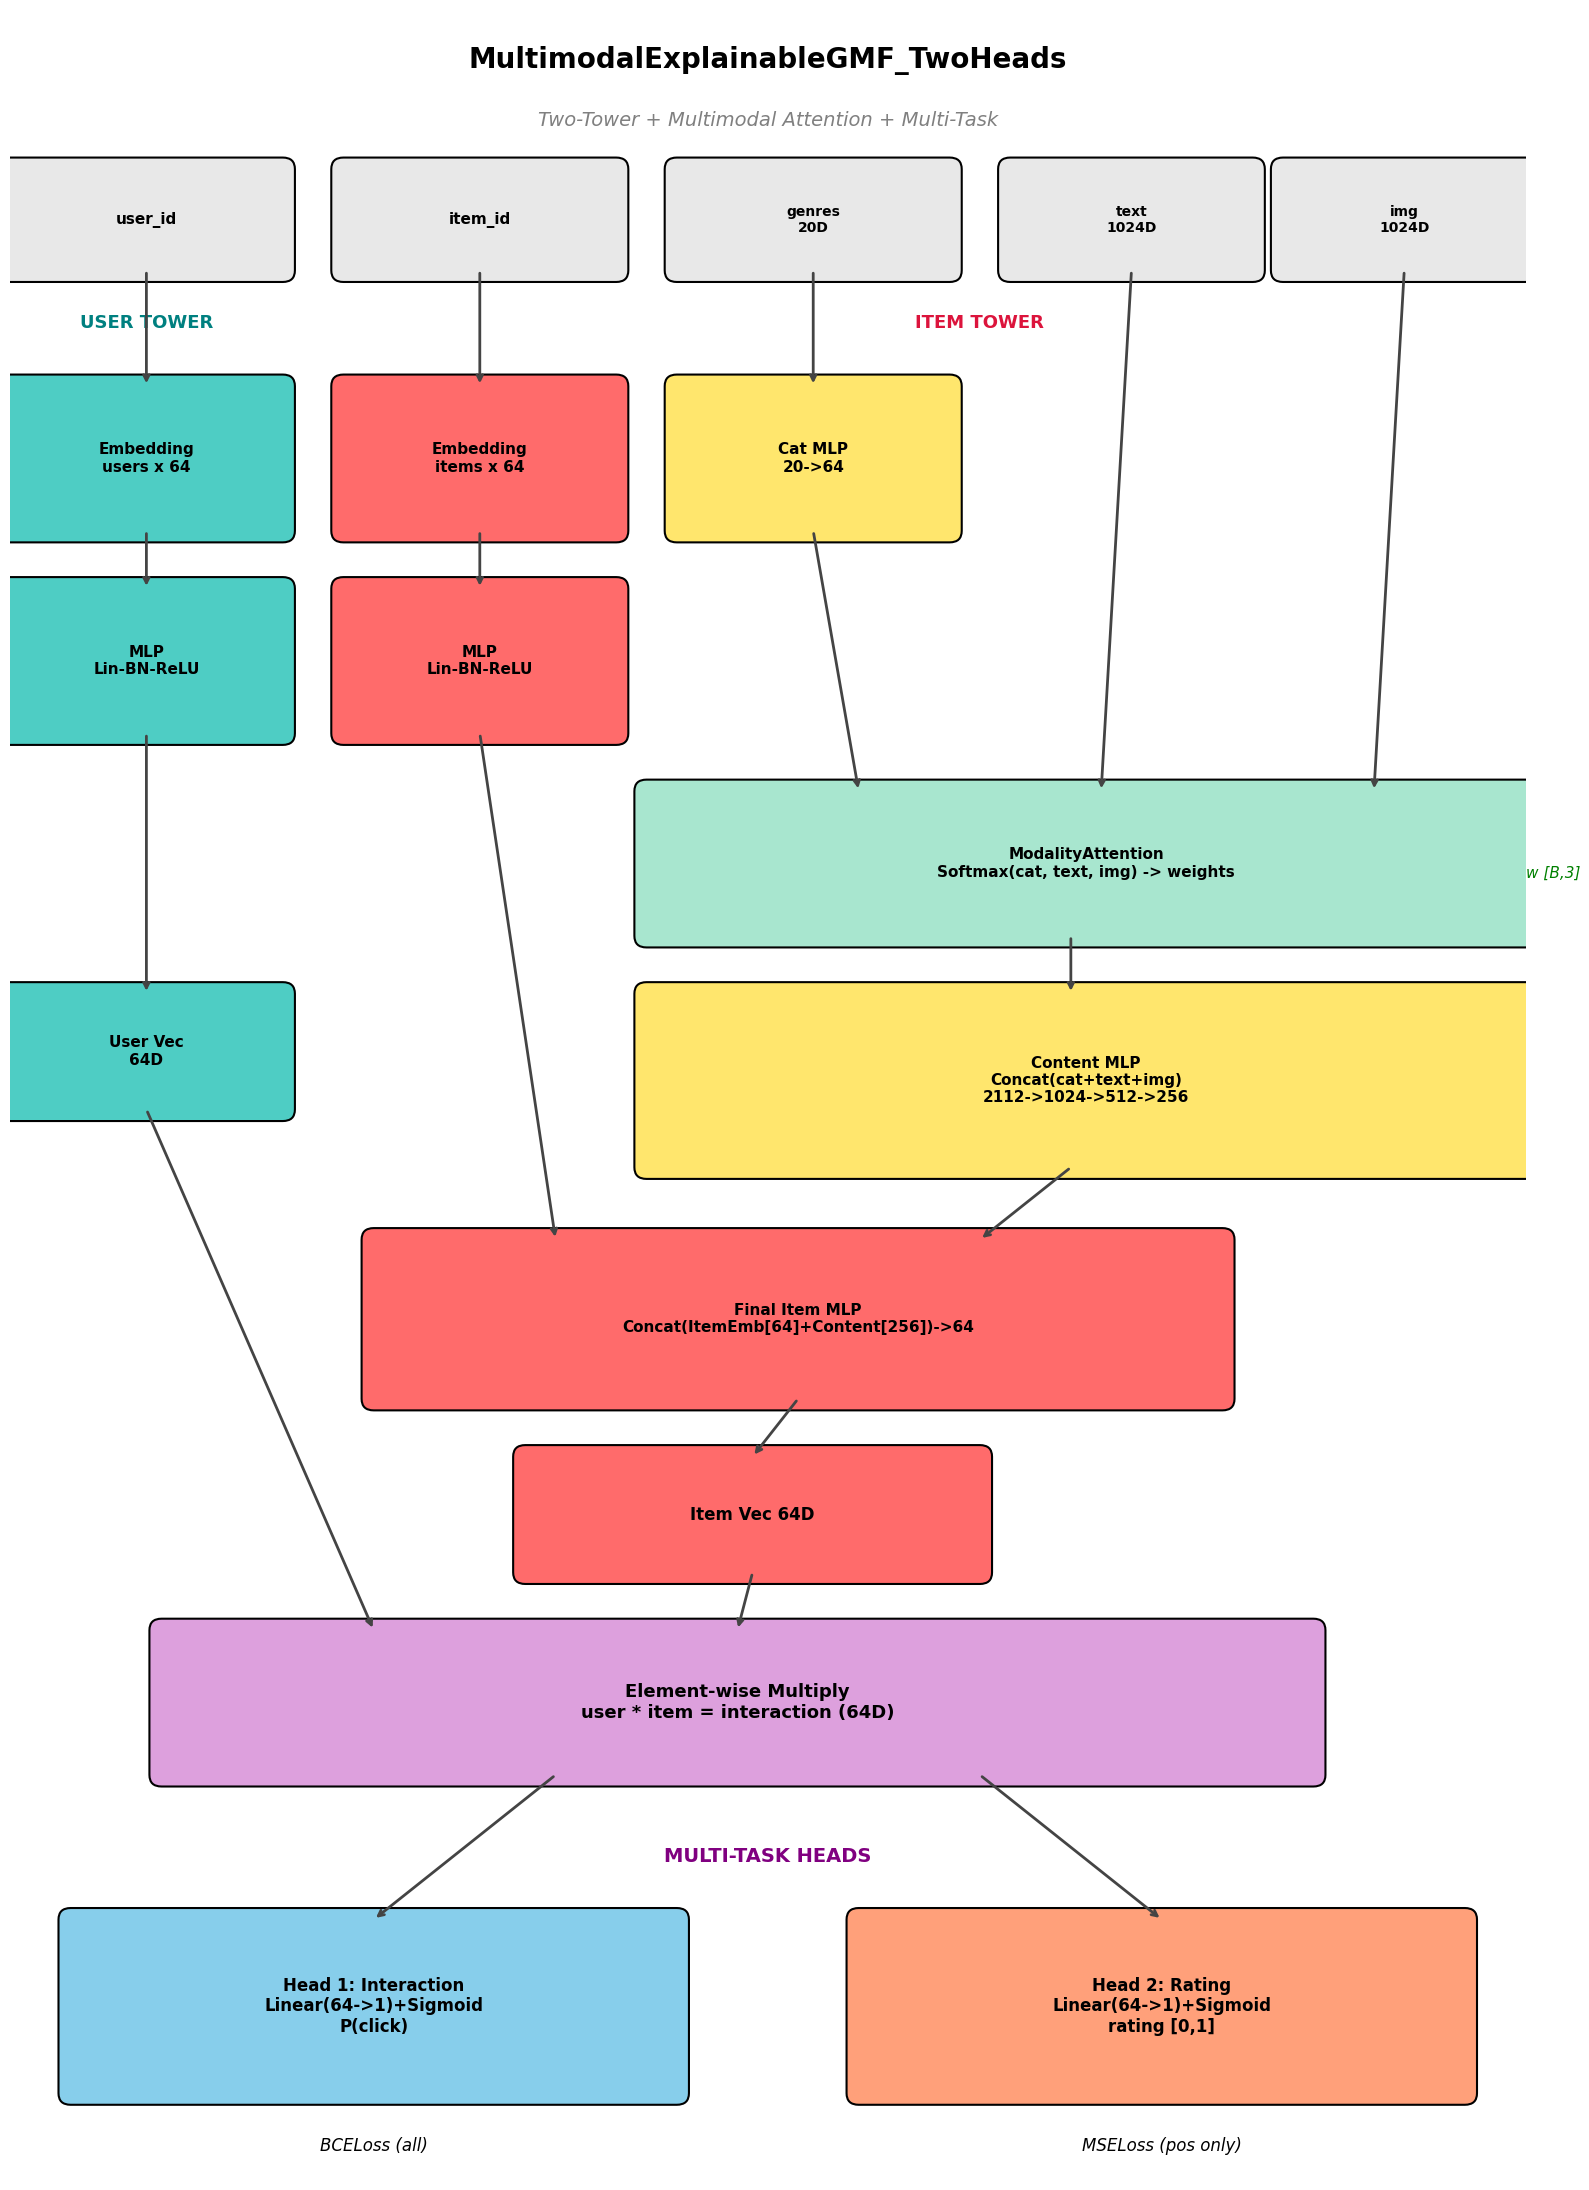

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(1, 1, figsize=(16, 22))
ax.set_xlim(0, 5)
ax.set_ylim(0, 7.5)
ax.axis('off')

# Colores
c_input = '#E8E8E8'
c_user = '#4ECDC4'
c_item_emb = '#FF6B6B'
c_content = '#FFE66D'
c_attention = '#A8E6CF'
c_fusion = '#DDA0DD'
c_head_int = '#87CEEB'
c_head_rat = '#FFA07A'

def box(x, y, w, h, label, color, fs=13):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04",
                       facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=fs, fontweight='bold')

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='#444'))

# TITULO
ax.text(2.5, 7.3, "MultimodalExplainableGMF_TwoHeads", ha='center', fontsize=20, fontweight='bold')
ax.text(2.5, 7.1, "Two-Tower + Multimodal Attention + Multi-Task", ha='center', fontsize=14, style='italic', color='gray')

# INPUTS
box(0, 6.6, 0.9, 0.35, "user_id", c_input, 11)
box(1.1, 6.6, 0.9, 0.35, "item_id", c_input, 11)
box(2.2, 6.6, 0.9, 0.35, "genres\n20D", c_input, 10)
box(3.3, 6.6, 0.8, 0.35, "text\n1024D", c_input, 10)
box(4.2, 6.6, 0.8, 0.35, "img\n1024D", c_input, 10)

# USER TOWER
ax.text(0.45, 6.4, "USER TOWER", ha='center', fontsize=13, fontweight='bold', color='teal')
box(0, 5.7, 0.9, 0.5, "Embedding\nusers x 64", c_user, 11)
box(0, 5.0, 0.9, 0.5, "MLP\nLin-BN-ReLU", c_user, 11)
arrow(0.45, 6.6, 0.45, 6.2)
arrow(0.45, 5.7, 0.45, 5.5)

# ITEM TOWER
ax.text(3.2, 6.4, "ITEM TOWER", ha='center', fontsize=13, fontweight='bold', color='crimson')

box(1.1, 5.7, 0.9, 0.5, "Embedding\nitems x 64", c_item_emb, 11)
box(1.1, 5.0, 0.9, 0.5, "MLP\nLin-BN-ReLU", c_item_emb, 11)
arrow(1.55, 6.6, 1.55, 6.2)
arrow(1.55, 5.7, 1.55, 5.5)

box(2.2, 5.7, 0.9, 0.5, "Cat MLP\n20->64", c_content, 11)
arrow(2.65, 6.6, 2.65, 6.2)

# ATTENTION
box(2.1, 4.3, 2.9, 0.5, "ModalityAttention\nSoftmax(cat, text, img) -> weights", c_attention, 11)
arrow(2.65, 5.7, 2.8, 4.8)
arrow(3.7, 6.6, 3.6, 4.8)
arrow(4.6, 6.6, 4.5, 4.8)
ax.text(5, 4.5, "w [B,3]", fontsize=11, color='green', style='italic')

# CONTENT MLP
box(2.1, 3.5, 2.9, 0.6, "Content MLP\nConcat(cat+text+img)\n2112->1024->512->256", c_content, 11)
arrow(3.5, 4.3, 3.5, 4.1)

# FINAL ITEM MLP
box(1.2, 2.7, 2.8, 0.55, "Final Item MLP\nConcat(ItemEmb[64]+Content[256])->64", c_item_emb, 11)
arrow(1.55, 5.0, 1.8, 3.25)
arrow(3.5, 3.5, 3.2, 3.25)

# USER VECTOR
box(0, 3.7, 0.9, 0.4, "User Vec\n64D", c_user, 11)
arrow(0.45, 5.0, 0.45, 4.1)

# ITEM VECTOR
box(1.7, 2.1, 1.5, 0.4, "Item Vec 64D", c_item_emb, 12)
arrow(2.6, 2.7, 2.45, 2.5)

# ELEMENT-WISE
box(0.5, 1.4, 3.8, 0.5, "Element-wise Multiply\nuser * item = interaction (64D)", c_fusion, 13)
arrow(0.45, 3.7, 1.2, 1.9)
arrow(2.45, 2.1, 2.4, 1.9)

# TWO HEADS
ax.text(2.5, 1.1, "MULTI-TASK HEADS", ha='center', fontsize=14, fontweight='bold', color='purple')

box(0.2, 0.3, 2, 0.6, "Head 1: Interaction\nLinear(64->1)+Sigmoid\nP(click)", c_head_int, 12)
box(2.8, 0.3, 2, 0.6, "Head 2: Rating\nLinear(64->1)+Sigmoid\nrating [0,1]", c_head_rat, 12)
arrow(1.8, 1.4, 1.2, 0.9)
arrow(3.2, 1.4, 3.8, 0.9)

# Loss
ax.text(1.2, 0.1, "BCELoss (all)", ha='center', fontsize=12, style='italic')
ax.text(3.8, 0.1, "MSELoss (pos only)", ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.savefig("hymmrec_twoheads_architecture.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Resultados

HPO Best Trial
  Mensajes totales: 100
  Epochs: 5


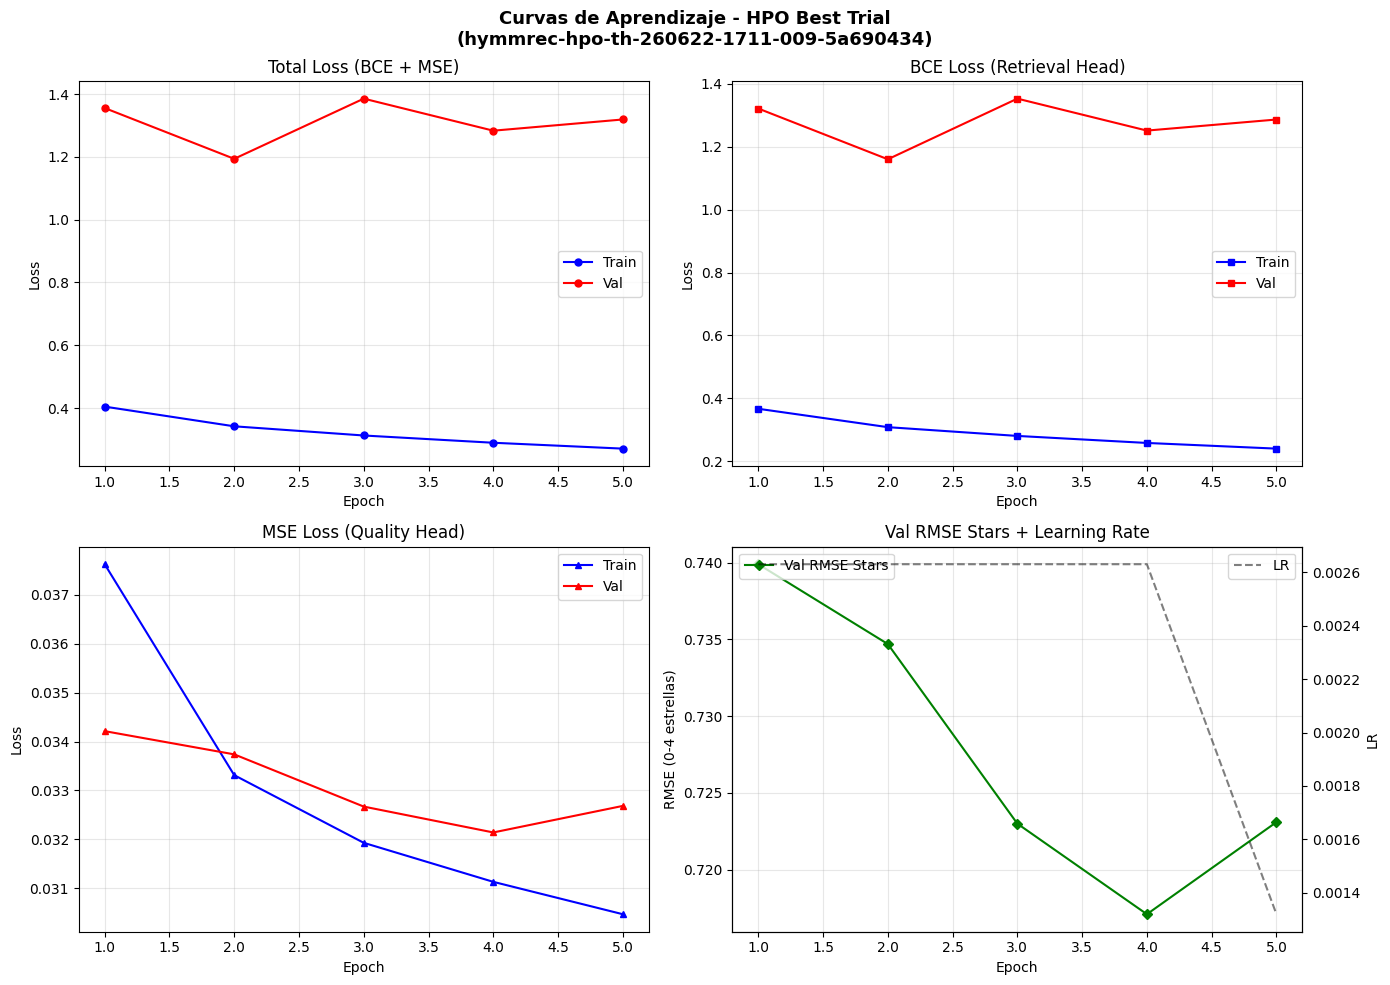

Guardado: learning_curves_hpo_best.png

Training Final
  Mensajes totales: 95
  Epochs: 8


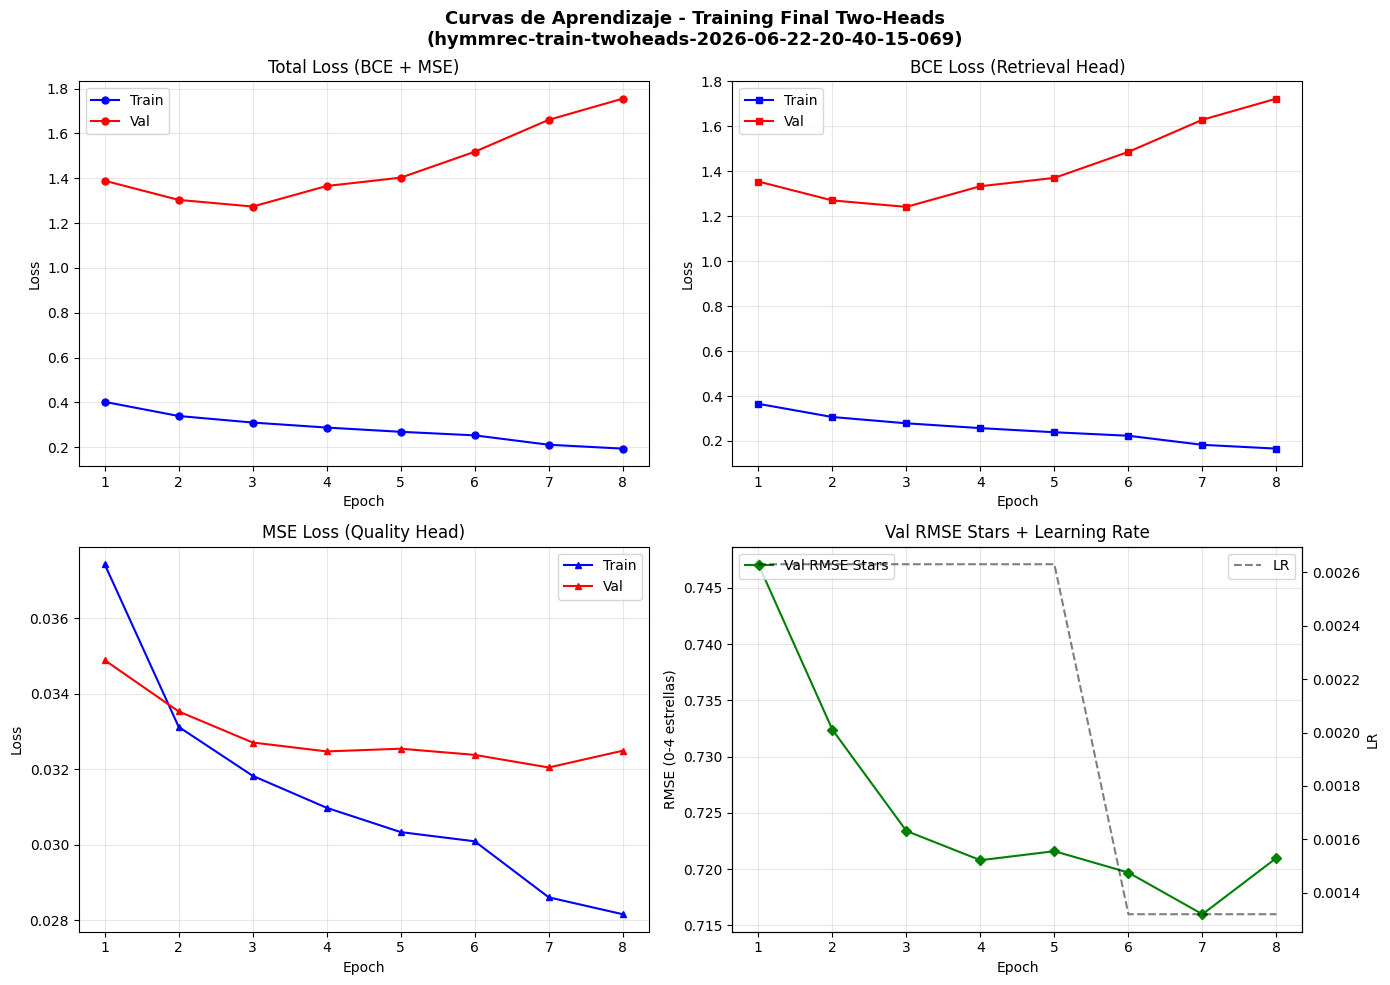

Guardado: learning_curves_final.png


In [14]:
import boto3
import re
import matplotlib.pyplot as plt

logs = boto3.client("logs", region_name="us-east-1")
log_group = "/aws/sagemaker/TrainingJobs"

def get_all_log_messages(job_name):
    """Obtiene todos los mensajes de CloudWatch con paginación correcta."""
    streams = logs.describe_log_streams(
        logGroupName=log_group,
        logStreamNamePrefix=job_name
    )
    if not streams["logStreams"]:
        return []

    all_messages = []
    for stream in streams["logStreams"]:
        next_token = None
        while True:
            kwargs = {
                "logGroupName": log_group,
                "logStreamName": stream["logStreamName"],
                "startFromHead": True,
                "limit": 10000,
            }
            if next_token:
                kwargs["nextToken"] = next_token

            response = logs.get_log_events(**kwargs)
            events = response["events"]
            if events:
                all_messages.extend([e["message"] for e in events])

            new_token = response["nextForwardToken"]
            if new_token == next_token:
                break
            next_token = new_token

    return all_messages

def parse_metrics(messages):
    """Parsea métricas de líneas tipo 'Epoch N | train_total_loss=X; ...'"""
    train_total, train_bce, train_mse = [], [], []
    val_total, val_bce, val_mse, val_rmse_stars = [], [], [], []
    lrs = []

    for msg in messages:
        # Solo procesar líneas que empiecen con "Epoch "
        if not msg.strip().startswith("Epoch "):
            continue

        m = re.search(r"train_total_loss=([0-9.]+);", msg)
        if m: train_total.append(float(m.group(1)))

        m = re.search(r"train_bce=([0-9.]+);", msg)
        if m: train_bce.append(float(m.group(1)))

        # train_mse puede no estar en HPO (está implícito en total-bce)
        m = re.search(r"train_mse=([0-9.]+);", msg)
        if m: train_mse.append(float(m.group(1)))

        m = re.search(r"val_total_loss=([0-9.]+);", msg)
        if m: val_total.append(float(m.group(1)))

        m = re.search(r"val_bce=([0-9.]+);", msg)
        if m: val_bce.append(float(m.group(1)))

        m = re.search(r"val_mse=([0-9.]+);", msg)
        if m: val_mse.append(float(m.group(1)))

        m = re.search(r"val_rmse_stars=([0-9.]+);", msg)
        if m: val_rmse_stars.append(float(m.group(1)))

        m = re.search(r"lr=([0-9.eE+\-]+);", msg)
        if m: lrs.append(float(m.group(1)))

    # Para HPO, train_mse no se imprime separado, calcularlo
    if not train_mse and train_total and train_bce:
        train_mse = [t - b for t, b in zip(train_total, train_bce)]

    n = min(len(train_total), len(val_total), len(val_bce), len(val_mse), len(val_rmse_stars))

    if n == 0:
        return None

    return {
        "train_total": train_total[:n],
        "train_bce": train_bce[:n],
        "train_mse": train_mse[:n],
        "val_total": val_total[:n],
        "val_bce": val_bce[:n],
        "val_mse": val_mse[:n],
        "val_rmse_stars": val_rmse_stars[:n],
        "lr": lrs[:n],
    }

def plot_learning_curves(metrics, title, filename):
    n = len(metrics["val_total"])
    epochs = range(1, n + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    axes[0,0].plot(epochs, metrics["train_total"], "b-o", ms=5, label="Train")
    axes[0,0].plot(epochs, metrics["val_total"], "r-o", ms=5, label="Val")
    axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
    axes[0,0].set_title("Total Loss (BCE + MSE)")
    axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(epochs, metrics["train_bce"], "b-s", ms=5, label="Train")
    axes[0,1].plot(epochs, metrics["val_bce"], "r-s", ms=5, label="Val")
    axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Loss")
    axes[0,1].set_title("BCE Loss (Retrieval Head)")
    axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

    axes[1,0].plot(epochs, metrics["train_mse"], "b-^", ms=5, label="Train")
    axes[1,0].plot(epochs, metrics["val_mse"], "r-^", ms=5, label="Val")
    axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss")
    axes[1,0].set_title("MSE Loss (Quality Head)")
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(epochs, metrics["val_rmse_stars"], "g-D", ms=5, label="Val RMSE Stars")
    axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("RMSE (0-4 estrellas)")
    axes[1,1].set_title("Val RMSE Stars + Learning Rate")
    axes[1,1].legend(loc="upper left"); axes[1,1].grid(True, alpha=0.3)
    if metrics["lr"]:
        ax2 = axes[1,1].twinx()
        ax2.plot(epochs, metrics["lr"], "k--", alpha=0.5, label="LR")
        ax2.set_ylabel("LR"); ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {filename}")

# ============================================================
# EJECUTAR
# ============================================================

# HPO Best Trial
print("=" * 60)
print("HPO Best Trial")
print("=" * 60)
msgs = get_all_log_messages("hymmrec-hpo-th-260622-1711-009-5a690434")
print(f"  Mensajes totales: {len(msgs)}")
hpo_metrics = parse_metrics(msgs)
if hpo_metrics:
    print(f"  Epochs: {len(hpo_metrics['val_total'])}")
    plot_learning_curves(hpo_metrics,
        "Curvas de Aprendizaje - HPO Best Trial\n(hymmrec-hpo-th-260622-1711-009-5a690434)",
        "learning_curves_hpo_best.png")
else:
    print("  No se encontraron métricas")

# Training Final
print("\n" + "=" * 60)
print("Training Final")
print("=" * 60)
msgs = get_all_log_messages("hymmrec-train-twoheads-2026-06-22-20-40-15-069")
print(f"  Mensajes totales: {len(msgs)}")
final_metrics = parse_metrics(msgs)
if final_metrics:
    print(f"  Epochs: {len(final_metrics['val_total'])}")
    plot_learning_curves(final_metrics,
        "Curvas de Aprendizaje - Training Final Two-Heads\n(hymmrec-train-twoheads-2026-06-22-20-40-15-069)",
        "learning_curves_final.png")
else:
    print("  No se encontraron métricas")


HPO Best Trial
  Mensajes totales: 100
  Epochs: 5


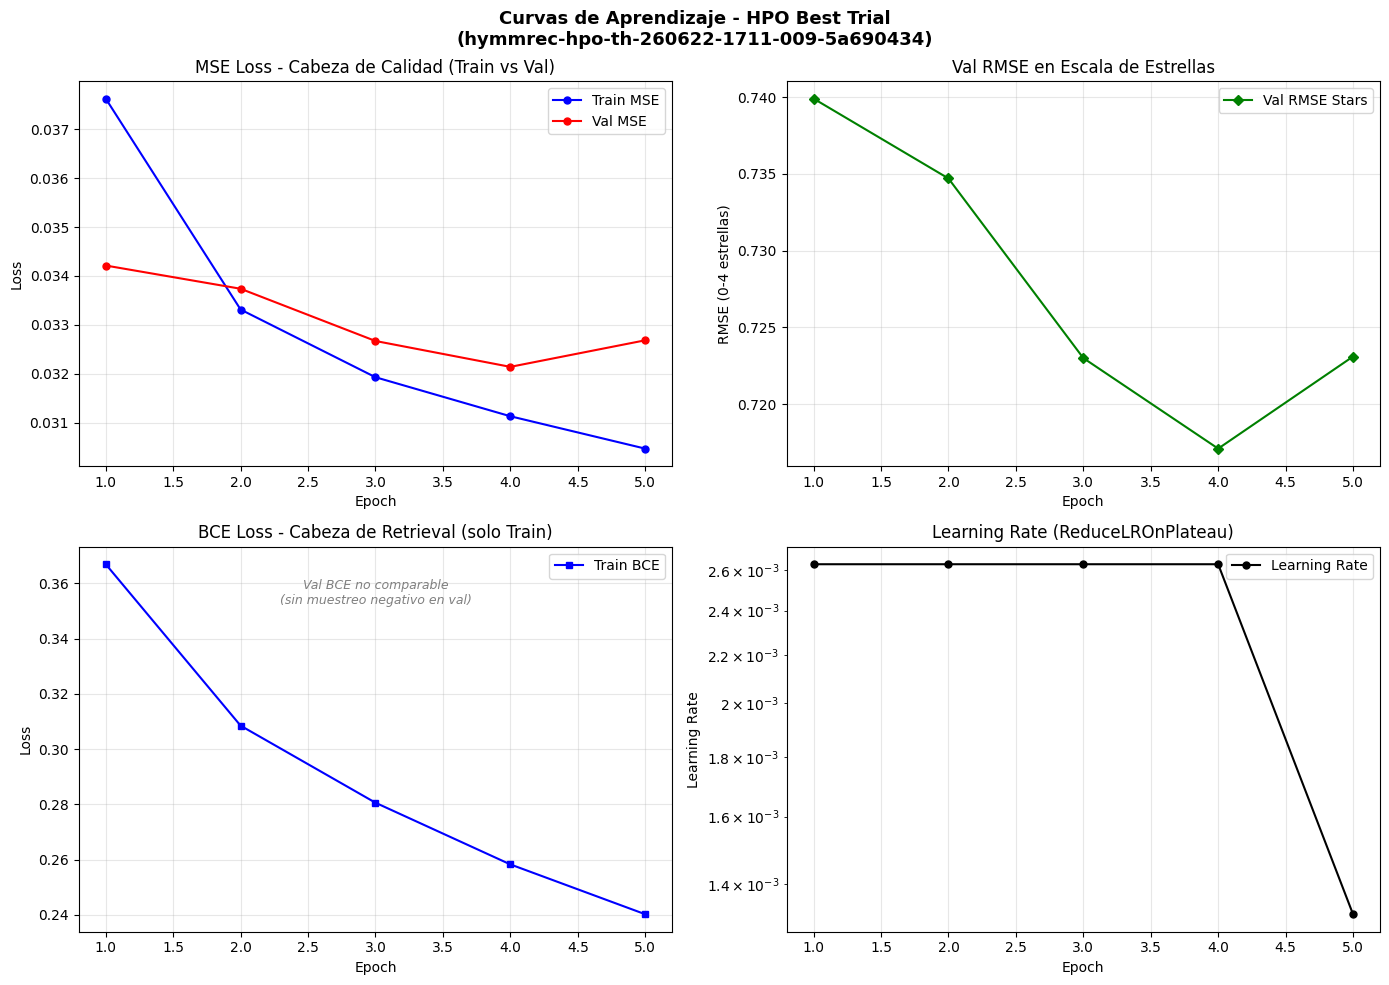

Guardado: learning_curves_hpo_best.png

Training Final
  Mensajes totales: 95
  Epochs: 8


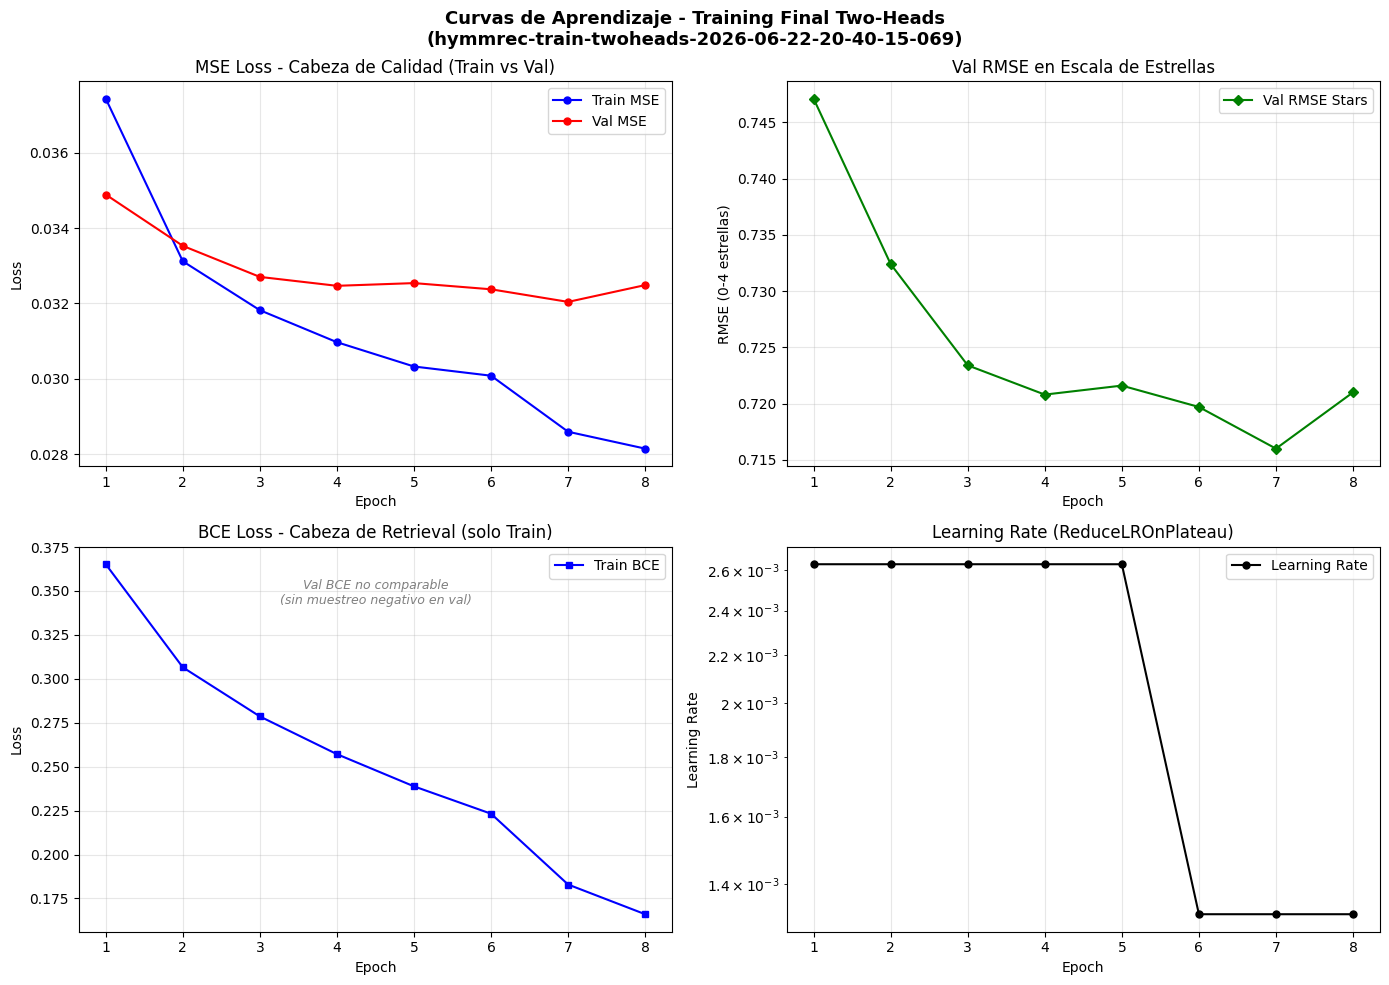

Guardado: learning_curves_final.png


In [15]:
import boto3
import re
import matplotlib.pyplot as plt

logs = boto3.client("logs", region_name="us-east-1")
log_group = "/aws/sagemaker/TrainingJobs"

def get_all_log_messages(job_name):
    """Obtiene todos los mensajes de CloudWatch con paginación correcta."""
    streams = logs.describe_log_streams(
        logGroupName=log_group,
        logStreamNamePrefix=job_name
    )
    if not streams["logStreams"]:
        return []

    all_messages = []
    for stream in streams["logStreams"]:
        next_token = None
        while True:
            kwargs = {
                "logGroupName": log_group,
                "logStreamName": stream["logStreamName"],
                "startFromHead": True,
                "limit": 10000,
            }
            if next_token:
                kwargs["nextToken"] = next_token

            response = logs.get_log_events(**kwargs)
            events = response["events"]
            if events:
                all_messages.extend([e["message"] for e in events])

            new_token = response["nextForwardToken"]
            if new_token == next_token:
                break
            next_token = new_token

    return all_messages

def parse_metrics(messages):
    """Parsea métricas de líneas tipo 'Epoch N | train_total_loss=X; ...'"""
    train_total, train_bce, train_mse = [], [], []
    val_mse, val_rmse_stars = [], []
    lrs = []

    for msg in messages:
        if not msg.strip().startswith("Epoch "):
            continue

        m = re.search(r"train_total_loss=([0-9.]+);", msg)
        if m: train_total.append(float(m.group(1)))

        m = re.search(r"train_bce=([0-9.]+);", msg)
        if m: train_bce.append(float(m.group(1)))

        m = re.search(r"train_mse=([0-9.]+);", msg)
        if m: train_mse.append(float(m.group(1)))

        m = re.search(r"val_mse=([0-9.]+);", msg)
        if m: val_mse.append(float(m.group(1)))

        m = re.search(r"val_rmse_stars=([0-9.]+);", msg)
        if m: val_rmse_stars.append(float(m.group(1)))

        m = re.search(r"lr=([0-9.eE+\-]+);", msg)
        if m: lrs.append(float(m.group(1)))

    # Para HPO, train_mse no se imprime separado, calcularlo
    if not train_mse and train_total and train_bce:
        train_mse = [t - b for t, b in zip(train_total, train_bce)]

    n = min(len(train_bce), len(train_mse), len(val_mse), len(val_rmse_stars))

    if n == 0:
        return None

    return {
        "train_bce": train_bce[:n],
        "train_mse": train_mse[:n],
        "val_mse": val_mse[:n],
        "val_rmse_stars": val_rmse_stars[:n],
        "lr": lrs[:n],
    }

def plot_learning_curves(metrics, title, filename):
    n = len(metrics["val_mse"])
    epochs = range(1, n + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # MSE Loss: Train vs Val (comparable, ambas sobre positivos reales)
    axes[0, 0].plot(epochs, metrics["train_mse"], "b-o", ms=5, label="Train MSE")
    axes[0, 0].plot(epochs, metrics["val_mse"], "r-o", ms=5, label="Val MSE")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("MSE Loss - Cabeza de Calidad (Train vs Val)")
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    # Val RMSE Stars (métrica de calidad en escala real)
    axes[0, 1].plot(epochs, metrics["val_rmse_stars"], "g-D", ms=5, label="Val RMSE Stars")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("RMSE (0-4 estrellas)")
    axes[0, 1].set_title("Val RMSE en Escala de Estrellas")
    axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    # Train BCE (solo train - señal de discriminación)
    axes[1, 0].plot(epochs, metrics["train_bce"], "b-s", ms=5, label="Train BCE")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("BCE Loss - Cabeza de Retrieval (solo Train)")
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].annotate(
        "Val BCE no comparable\n(sin muestreo negativo en val)",
        xy=(0.5, 0.85), xycoords="axes fraction",
        fontsize=9, ha="center", style="italic", color="gray"
    )

    # Learning Rate
    if metrics["lr"]:
        axes[1, 1].plot(epochs, metrics["lr"], "k-o", ms=5, label="Learning Rate")
        axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning Rate")
        axes[1, 1].set_title("Learning Rate (ReduceLROnPlateau)")
        axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_yscale("log")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {filename}")

# ============================================================
# EJECUTAR
# ============================================================

# HPO Best Trial
print("=" * 60)
print("HPO Best Trial")
print("=" * 60)
msgs = get_all_log_messages("hymmrec-hpo-th-260622-1711-009-5a690434")
print(f"  Mensajes totales: {len(msgs)}")
hpo_metrics = parse_metrics(msgs)
if hpo_metrics:
    print(f"  Epochs: {len(hpo_metrics['val_mse'])}")
    plot_learning_curves(hpo_metrics,
        "Curvas de Aprendizaje - HPO Best Trial\n(hymmrec-hpo-th-260622-1711-009-5a690434)",
        "learning_curves_hpo_best.png")
else:
    print("  No se encontraron métricas")

# Training Final
print("\n" + "=" * 60)
print("Training Final")
print("=" * 60)
msgs = get_all_log_messages("hymmrec-train-twoheads-2026-06-22-20-40-15-069")
print(f"  Mensajes totales: {len(msgs)}")
final_metrics = parse_metrics(msgs)
if final_metrics:
    print(f"  Epochs: {len(final_metrics['val_mse'])}")
    plot_learning_curves(final_metrics,
        "Curvas de Aprendizaje - Training Final Two-Heads\n(hymmrec-train-twoheads-2026-06-22-20-40-15-069)",
        "learning_curves_final.png")
else:
    print("  No se encontraron métricas")
